In [1]:
from run_kfold import Config, get_activation_class, load_inputs, make_outerkfold_inner_split, get_loss_class
import os 
import scipy as sp
import numpy as np
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr


In [2]:
import argparse

p = argparse.ArgumentParser()

# Add all your arguments here
p.add_argument("--results_dir", default="kfold_results")
p.add_argument("--folder_name", default="regression")
p.add_argument("--method_data", default="max_counts")
p.add_argument("--seed", type = int, default=0)


# Parse from list (works in Jupyter)
args = p.parse_args([
    "--results_dir", "kfold_results",
    "--folder_name", "regression",
    "--method_data", "max_counts",
    "--seed", 0,
])

print("Arguments:")
for arg, value in vars(args).items():
    print(f"  {arg}: {value}")



Arguments:
  results_dir: kfold_results
  folder_name: regression
  method_data: max_counts
  seed: 0


In [3]:
cfg = Config(
    results_dir=args.results_dir,
    folder_name=args.folder_name,
    method_data=args.method_data,
    seed=args.seed,
    )

In [4]:
folder_dir = os.path.join(cfg.results_dir, cfg.folder_name)
os.makedirs(folder_dir, exist_ok=True)

In [5]:
# # load data
Xs_raw, Z, Y_imp_ilr, cell_type_proportions_df = load_inputs(cfg)

# # folds
S = len(Xs_raw)
folds = make_outerkfold_inner_split(
    S,
    n_splits=cfg.n_splits,
    seed=cfg.seed,
    shuffle=True,
    inner_val_frac_of_trainval=cfg.inner_val_frac_of_trainval,
)


/data1/soldatr/luan/projects/cell_tissue_phenotype/uv_env/.venv/lib/python3.11/site-packages/skbio/util/_warning.py:40: DeprecationWarning: `multiplicative_replacement` was renamed to `multi_replace` in 0.6.0. The old name is kept as an alias but is deprecated.
  warn(message, warning)


In [6]:
folds[0]

{'train': array([ 70,  56, 114,  96, 210,  62,  76, 181, 120,  68, 215,  17,  69,
        165,  80, 213, 220, 135,  81,  58,  23, 105, 103, 198, 170, 130,
         88, 113, 142, 116,  50,  13, 158, 211, 122, 191, 100,  67,  98,
         43, 124, 180,  47,  72,  40,   0,  59, 224,  35,  84,  61, 148,
        119, 102,  74, 216,  33,  77, 223, 173, 194, 221, 138, 201, 172,
        209, 171,  29,  99,  82, 214,  30,  86,  39, 152, 208,  51, 136,
        177,  16,  57, 115,  94, 188, 192, 110, 218, 185, 169,  20,  65,
        141,  78,   6,  38,  25,  27, 212, 154,  22,   4, 123,  28,  21,
        109, 162, 205,  14, 155,  95,  66, 219,  34, 174,  79,  24, 196,
        163, 167, 200, 127,  91, 186, 132, 206,  73, 160, 140, 150,  49,
         10, 175,  83,   2,   1, 199, 112, 182,  46, 133,  26,  60, 157,
        146]),
 'val': array([ 54,  45, 184,  42, 147,  53,  19,  11, 204, 195, 164,  31, 222,
        117,   9,  71, 151,  32, 189,  52,   3, 129, 118, 217,  48, 128,
        203,  85,  3

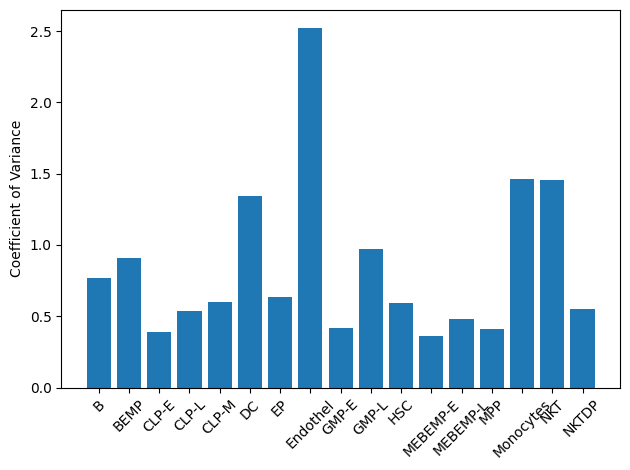

In [7]:
import matplotlib.pyplot as plt

ct_mean = cell_type_proportions_df.mean(axis = 0)
ct_std = cell_type_proportions_df.std(axis = 0)
ct_cv = ct_std / ct_mean

plt.bar(cell_type_proportions_df.columns.tolist(), ct_cv)
plt.xticks(rotation = 45)
plt.ylabel('Coefficient of Variance')
plt.tight_layout()
plt.show()

[0.37660513 0.54345486 0.66924373 0.76593229 0.82699431 0.86768237
 0.90056301 0.92560197 0.93976189 0.9531579  0.96583064 0.97643467
 0.98585606 0.99242933 0.99805606 1.         1.        ]


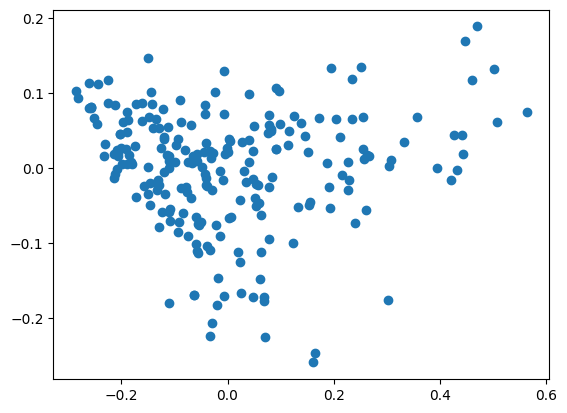

In [8]:
def plot_PCA(X):
    X_centered = X - X.mean(axis = 0, keepdims = True)
    U, S, Vt = np.linalg.svd(X_centered, full_matrices = False)
    PCs =  U * S #same as U @ np.diag(S)
    print(np.cumsum(S/S.sum()))
    # import matplotlib.pyplot as plt
    plt.scatter(PCs[:, 0], PCs[:, 1])

plot_PCA(cell_type_proportions_df.to_numpy())

In [9]:
# Y_ilr_cv = np.std(Y_imp_ilr, axis = 0, keepdims = True) / np.abs(np.mean(Y_imp_ilr, axis = 0, keepdims = True))

In [10]:
from regression.neural_network.dataclass_models import DataInputs, ModelHyperparams, TrainSetup
from regression.neural_network.parallel import run_one_fold

# Create dataclasses (shared across folds in this process)
data = DataInputs(Xs_raw=Xs_raw,
                  Z=Z,
                  Y_imp_ilr=Y_imp_ilr,
                  # Y_imp_ilr=Y_imp_ilr * 1.0/(1.0 + Y_ilr_cv),
                  cell_type_proportions_df=cell_type_proportions_df)
                  # cell_type_proportions_df=cell_type_proportions_stablized_df)

bias = not cfg.recenter_y
loss_cls = get_loss_class(cfg.loss_fn)

# cfg.num_hidden_layers = 2
# cfg.hidden_features = [128, 32]
# cfg.activation_type = [nn.ReLU, nn.ReLU]

hyperparams = ModelHyperparams(hidden_features=cfg.hidden_features,
                               num_hidden_layers=cfg.num_hidden_layers,
                               activation=cfg.activation,
                               activation_type=cfg.activation_type, #check to store factory, not instance
                               dropout=cfg.dropout,
                               batch_norm=cfg.batch_norm,
                               bias=bias,
                               scaling_factor=cfg.scaling_factor,
                               method=cfg.method_train,
                               layer_norm=cfg.layer_norm,
                               loss_fn=loss_cls, #check to store factory, not instance
                               loss_fn_kwargs=cfg.loss_kwargs
                               )
setup = TrainSetup(batch_size=cfg.batch_size,
                   device=cfg.device,
                   epochs=cfg.epochs,
                   lr=cfg.lr,
                   weight_decay=cfg.weight_decay,
                   return_compositions=cfg.return_compositions)


In [11]:

fold = 2
fold_idxs = folds[fold]
res = run_one_fold(data, hyperparams, setup, fold=fold, fold_idxs=fold_idxs)


 15%|█▍        | 147/1000 [01:28<08:33,  1.66it/s]


In [12]:
res['trainer'].model

CompositionModel(
  (preprocessor): Preprocessor()
  (aggregator): Aggregator()
  (postprocessor): Postprocessor()
  (cell_predictor): CellPredictor(
    (network): Sequential(
      (0): Linear(in_features=17441, out_features=16, bias=True)
    )
  )
)

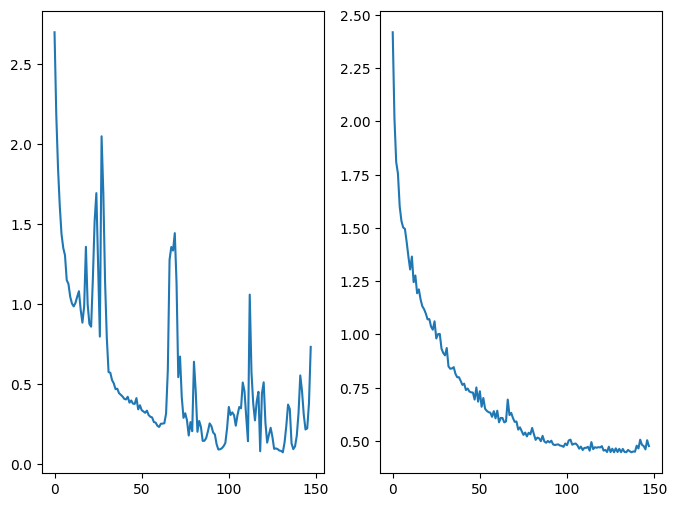

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))
plt.subplot(1,2,1)
plt.plot(res['train_mse_history'])
plt.subplot(1,2,2)
plt.plot(res['val_mse_history'])

In [14]:
res.keys()

dict_keys(['fold', 'train_mse_history', 'val_mse_history', 'test_mse', 'cor_list', 'rsq_list', 'test_res', 'trainer'])

In [15]:
results = res['test_res']
preds = results["preds"]             # (S_test, T) aligned with dataset_test indices
targets = results["targets"]         # (S_test, T)
ct_cor_list = res['cor_list']

In [16]:
import scipy as sp
import numpy as np
from scipy.stats import pearsonr
# cor_list = [pearsonr(preds[:, i], targets[:, i])[0] for i in np.arange(targets.shape[1])]
cor_list = [sp.stats.spearmanr(preds[:, i], targets[:, i])[0] for i in np.arange(targets.shape[1])]

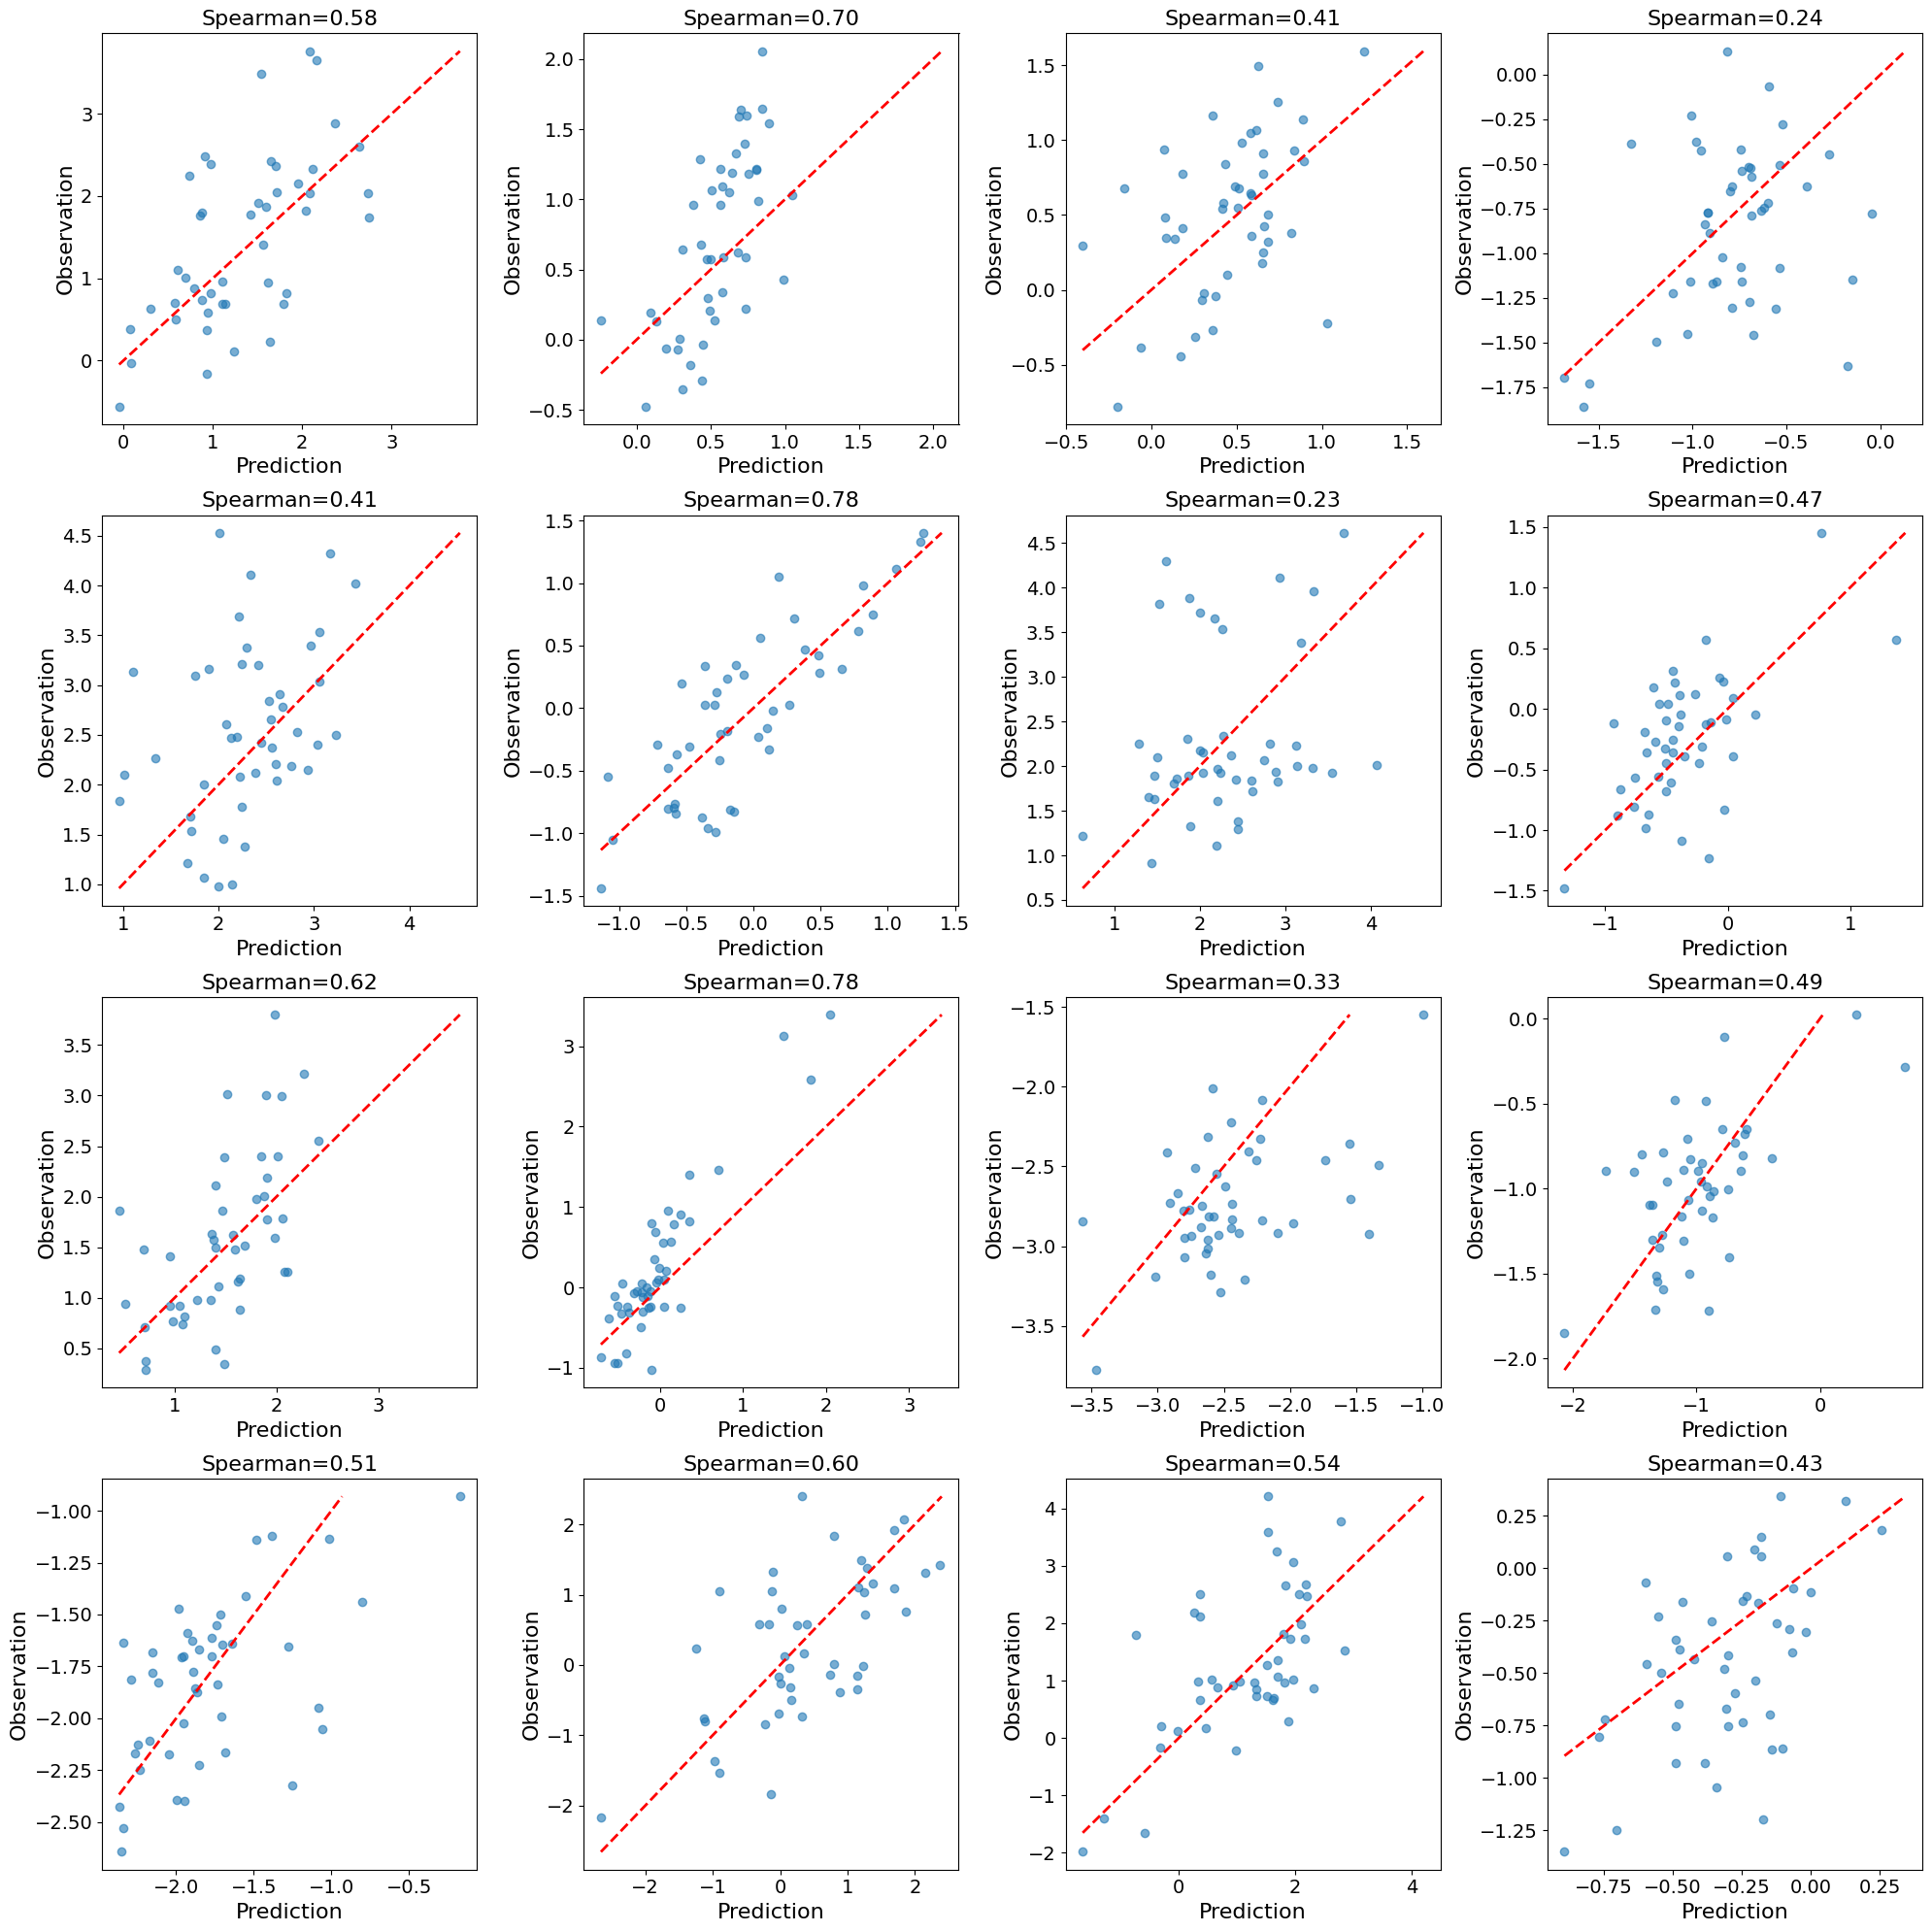

In [17]:

ncols = 4
nrows = round(targets.shape[1]/ncols) 

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(targets.shape[1]):
    axs[i].scatter(preds[:,i].ravel(), targets[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction', fontsize = 16)
    axs[i].set_ylabel('Observation', fontsize = 16)
    axs[i].tick_params(axis = 'both', labelsize = 14)
    # axs[i].set_xscale('log')
    # axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}")
    # axs[i].set_title(f"Pearson={cor_list[i]:.2f}", fontsize = 16)
    axs[i].set_title(f"Spearman={cor_list[i]:.2f}", fontsize = 16)

    min_val = min(preds[:, i].min(), preds[:, i].min())
    max_val = max(targets[:, i].max(), targets[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

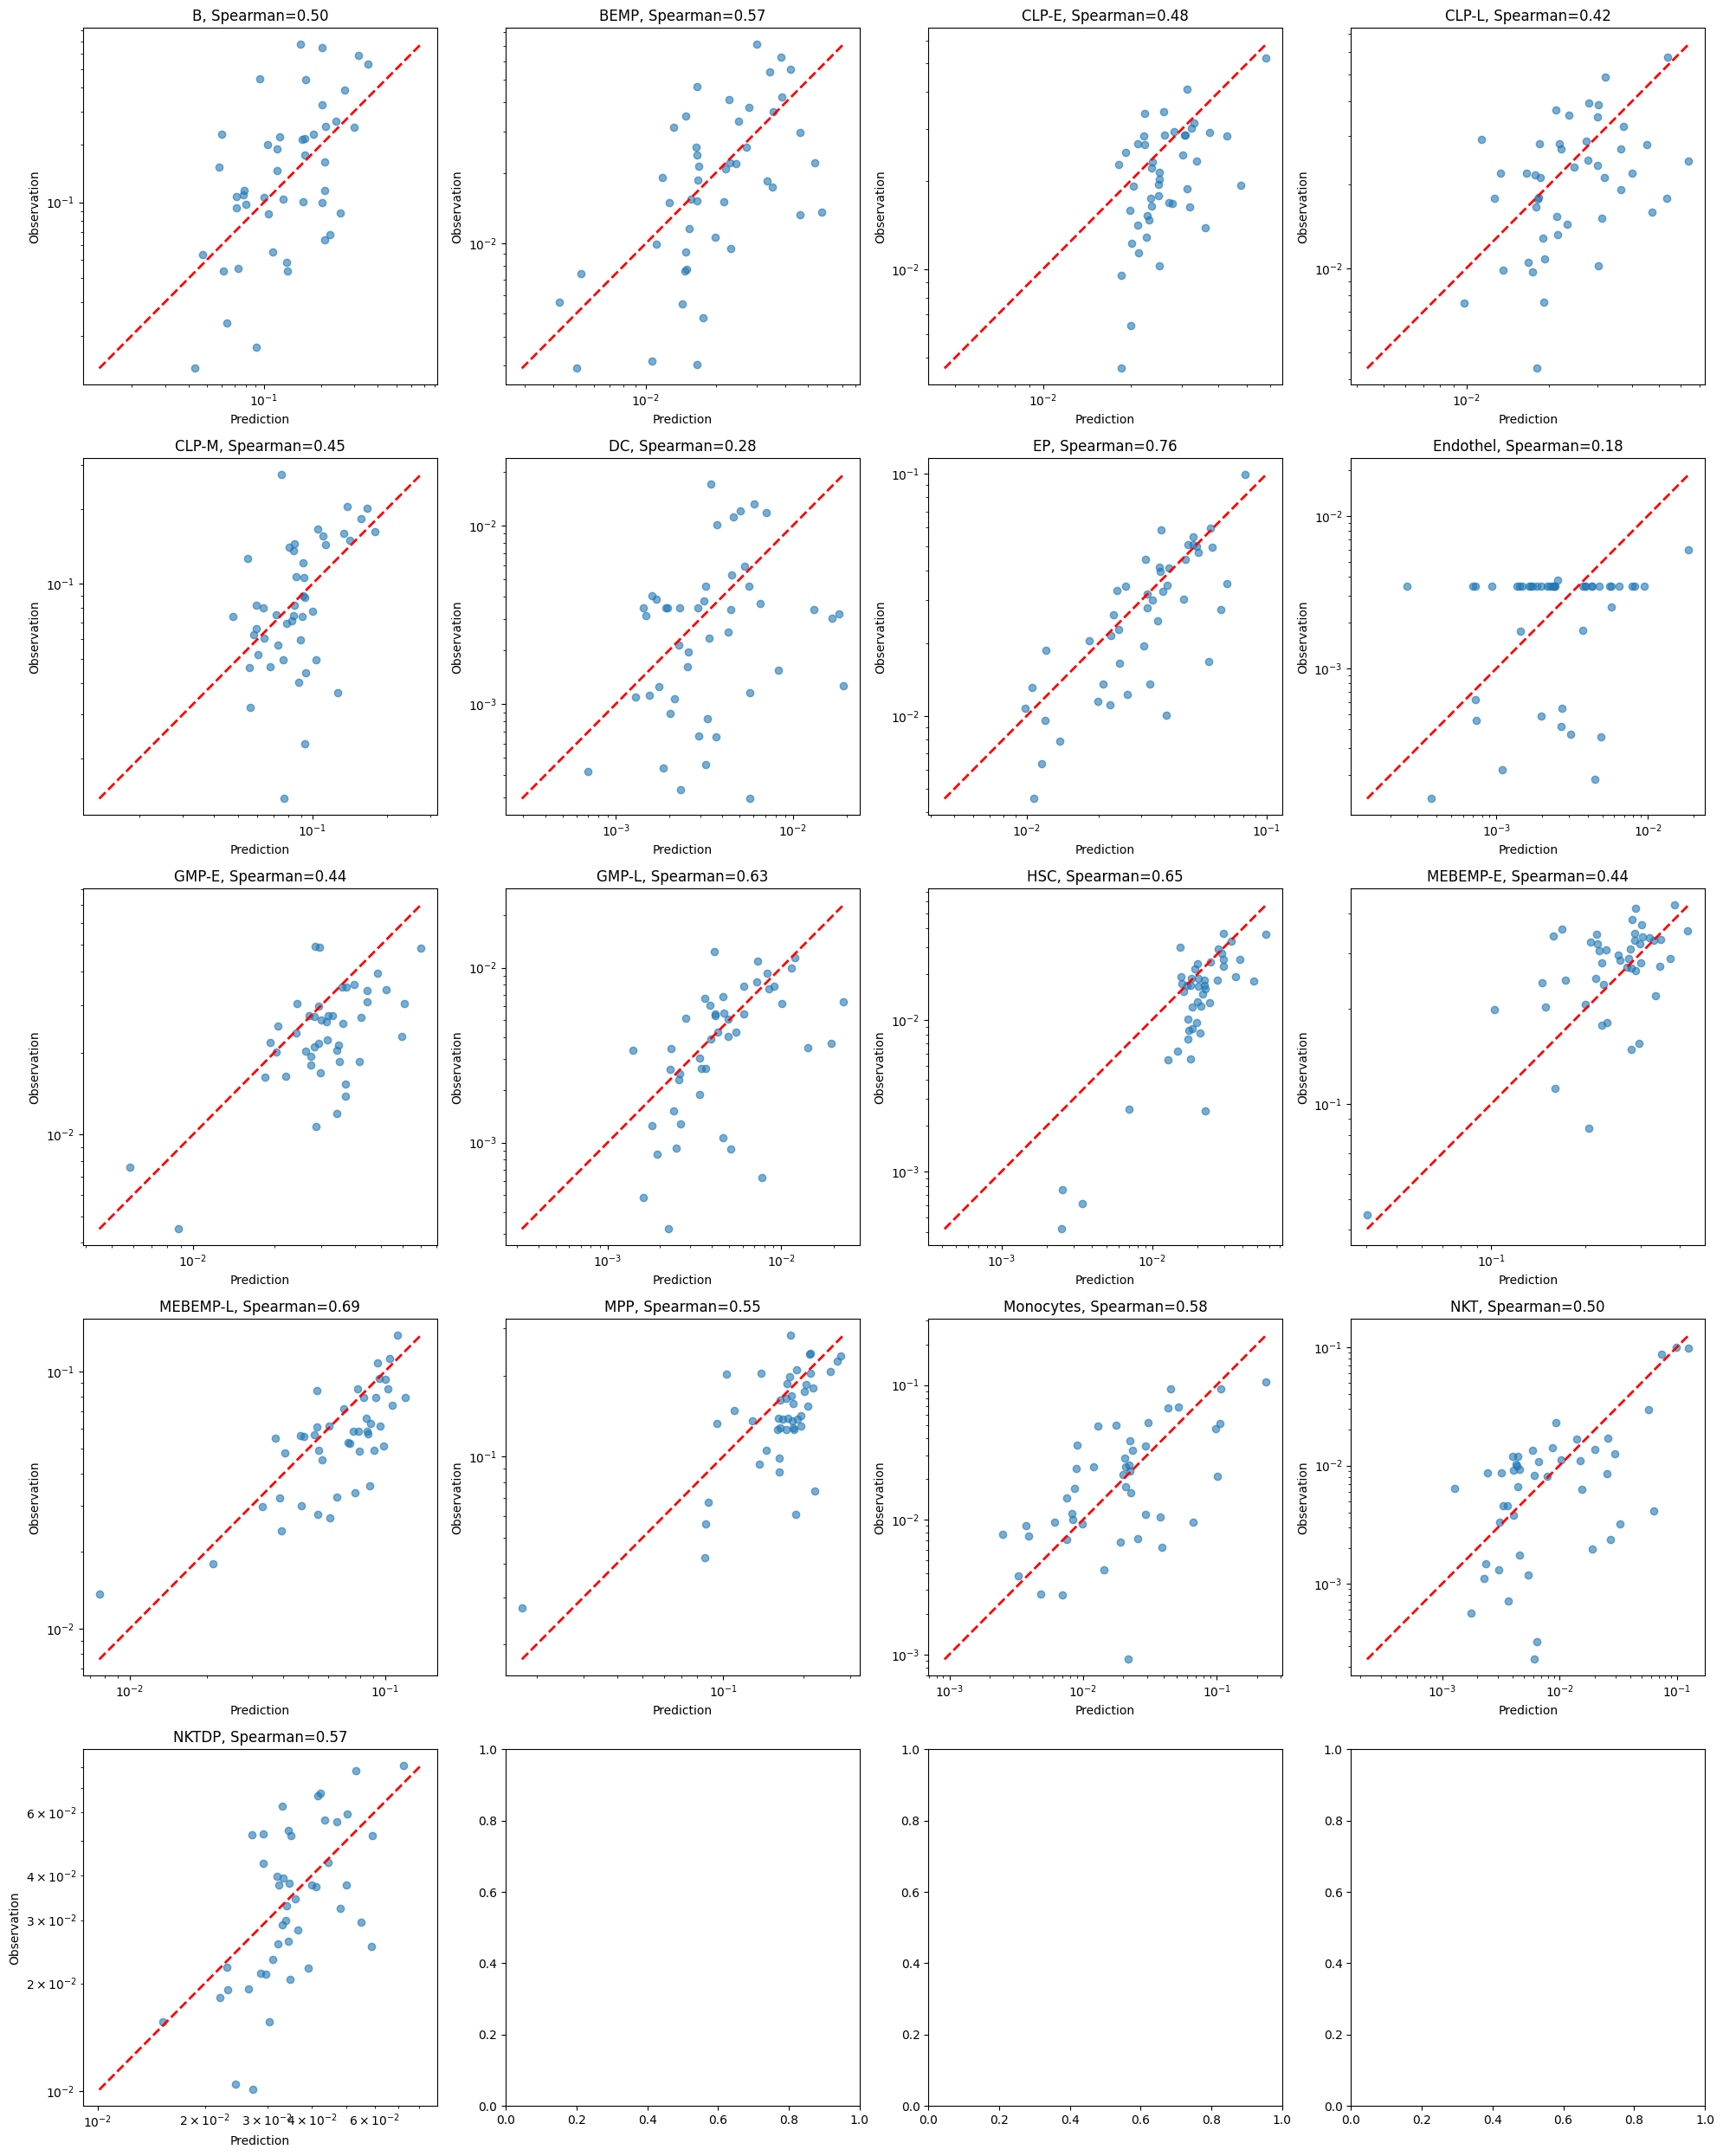

In [18]:
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr

ncols = 4
nrows = round(targets.shape[1]/ncols) + 1

ct_preds = ilr_inv(preds)
ct_obs = ilr_inv(targets)

# ct_cor = [np.corrcoef(ct_preds[:, i], ct_obs[:, i])[0][1] for i in range(cell_type_proportions_df.shape[1])]

ct_cor = [sp.stats.spearmanr(ct_preds[:, i], ct_obs[:, i])[0] for i in range(cell_type_proportions_df.shape[1])]

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(cell_type_proportions_df.shape[1]):
    axs[i].scatter(ct_preds[:, i].ravel(), ct_obs[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction')
    axs[i].set_ylabel('Observation')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Pearson={ct_cor[i]:.2f}")
    axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Spearman={ct_cor[i]:.2f}")

    min_val = min(ct_preds[:, i].min(), ct_obs[:, i].min())
    max_val = max(ct_preds[:, i].max(), ct_obs[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

In [19]:
import numpy as np
from scipy.sparse import issparse
from sklearn.preprocessing import normalize
from scipy.sparse import hstack, csr_matrix, spmatrix
from typing import Literal, Dict, List
import pandas as pd

def log_normalize_sparse(X, scale_factor = 1e4):
    """
    Normalize sparse matrix to proportions and apply log1p transform.
    
    Parameters:
    -----------
    X : scipy.sparse matrix
        Input sparse matrix (samples x features)
    
    Returns:
    --------
    X_transformed : scipy.sparse matrix
        Log-normalized sparse matrix
    """
    if not issparse(X):
        raise ValueError("Input must be a sparse matrix")
    
    # Normalize rows to sum to 1 (proportions)
    X_norm = normalize(X, norm='l1', axis=1)
    
    # Log-transform non-zero values only
    X_log = X_norm.copy()
    X_log.data = np.log1p(X_log.data*scale_factor)
    
    return X_log

def build_cell_ids_samples(Xs_raw, fold, split: Literal["train", "val", "test"] = "train"):
    '''
    Build list of sample IDs for each cell

    Return: 
    codes: a list storing sample IDs (also columns) each cells belong to
    (e.g., [0,0,0,1,1] means first column has 3 cells in sample 0, second column has 2 cells in sample 1
    '''
    
    ncells_list = [Xs_raw[i].shape[0] for i in fold[split]]
    codes = []
    for j, ncell in enumerate(ncells_list):
        codes.extend([j] * ncell)
    return codes

def build_sample_by_cell_matrix(nsamples, ncells, codes):
    '''
    nsamples: number of samples
    ncells: number of cells
    codes: id of each cells belonging to a particular sample

    Return:
    G: a sparse matrix where rows are cells, columns are sample IDs
    (e.g., array[[1, 0, 0],
                 [1, 0, 0],
                 [0, 1, 0],
                 [0, 1, 0])
    '''
    G = sp.sparse.csr_matrix(
            (np.ones(ncells, dtype=np.float32), (np.arange(ncells), codes)),
            shape=(ncells, nsamples)
        )
    return G

def do_pseudobulk(G, X):
    '''
    G: sample by cell matrix indicating which cells belong to which sample
    X: sparse gene expression matrix per sample
    '''
    return G.T@X




def build_X_design(X: spmatrix, 
                   Z: pd.DataFrame, 
                   fold: Dict[str, List[int]], 
                   split: Literal["train", "val", "test"] = "train") -> spmatrix:
    '''
    X: pseudobulk, sparse sample by gene matrix
    Z: covariate matrix (e.g., batch information, age)

    Return:
    X_design: concatenate X and Z together to get a sparse matrix
    '''
    Z_sparse = csr_matrix(Z.to_numpy()[fold[split], :])
    X_design = hstack([X, Z_sparse])
    return X_design


def X_var_matrix(X):
    X_mean = X.toarray().mean(axis = 0)
    X_centered = X.toarray() - X_mean
    return X_centered ** 2

In [20]:
import scipy as sp

# fold = 1
print(f'Using fold {fold}')

Xs_train = [Xs_raw[i] for i in folds[fold]['train']]
Xs_train = sp.sparse.vstack(Xs_train)
Xs_train_log = log_normalize_sparse(Xs_train)



Using fold 2


In [21]:
codes = build_cell_ids_samples(Xs_raw = Xs_raw, fold=folds[fold])


In [22]:


G = build_sample_by_cell_matrix(nsamples = len(folds[fold]['train']), 
                            ncells = Xs_train_log.shape[0],
                            codes = codes)

In [253]:
# Number of cells per sample/group
# reshape to 2D matrix
n_cells_per_group_train = np.bincount(codes).reshape(-1, 1)
n_cells_per_group_train.shape

(144, 1)

In [254]:
G_test = build_sample_by_cell_matrix(nsamples = 3, 
                            ncells = 10,
                            codes = [0,0,0,1,1,1,1,2,2,2])
G_test.toarray()

array([[1., 0., 0.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [0., 0., 1.]], dtype=float32)

In [25]:
Xs_pseudobulk_train = do_pseudobulk(G, Xs_train_log)

In [26]:

Xs_pseudobulk_train = Xs_pseudobulk_train / np.clip(n_cells_per_group_train, 1, None)
    

In [27]:
# from scipy.sparse import hstack, csr_matrix

# # Convert pandas DataFrame to sparse
# Z_train_sparse = csr_matrix(Z.to_numpy()[folds[0]['train'], :])

# # Horizontal stack (concatenate columns)
# X_design_HSC_MPP = hstack([Xs_pseudobulk_train, Z_train_sparse])


X_design_HSC_MPP = build_X_design(X = Xs_pseudobulk_train, Z = Z, fold = folds[fold], split = "train")

print(f"X_design shape: {X_design_HSC_MPP.shape}")
print(f"X_design type: {type(X_design_HSC_MPP)}")  # Sparse matrix



X_design shape: (144, 17579)
X_design type: <class 'scipy.sparse._coo.coo_matrix'>


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import numpy as np

# Prepare data
X_train = X_design_HSC_MPP.toarray()
Y_train = Y_imp_ilr[folds[fold]['train'], :]

# 1. Fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit and transform train

# check and the result is similar without gene mask

# pseudobulk_gene_mask = np.linalg.norm(X_train_scaled, ord = 1, axis = 0) >= 1e-3

# print(f"Number of low var genes: {(~pseudobulk_gene_mask).sum()}")

# X_train_scaled = X_train_scaled[:, pseudobulk_gene_mask]

# these are one-hot-encoding variables so no need to scale
X_train_scaled[:, -6:-1] = X_train[:, -6:-1]

                                  

In [29]:
X_train_scaled.shape

(144, 17579)

In [30]:

# Ridge with CV to find best alpha
alphas = np.logspace(-6, 4, 100)  # Test alphas from 0.001 to 1000
ridge_cv = RidgeCV(alphas=alphas, cv=5)  # 5-fold CV
ridge_cv.fit(X_train_scaled, Y_train)

print(f"Best alpha: {ridge_cv.alpha_}")

# Predict
# Y_pred_train = ridge_cv.predict(X_train)




Best alpha: 1e-06


In [255]:
Xs_test = [Xs_raw[i] for i in folds[fold]['test']]
Xs_test = sp.sparse.vstack(Xs_test)
Xs_test_log = log_normalize_sparse(Xs_test)

codes_test = build_cell_ids_samples(Xs_raw = Xs_raw, fold=folds[fold], split = "test")

G_test = build_sample_by_cell_matrix(nsamples = len(folds[fold]['test']), 
                            ncells = Xs_test_log.shape[0],
                            codes = codes_test)

# Number of cells per sample/group
# reshape to 2D matrix
n_cells_per_group_test = np.bincount(codes_test).reshape(-1, 1)
n_cells_per_group_test.shape


(45, 1)

In [32]:
# Test performance

Xs_pseudobulk_test = do_pseudobulk(G_test, Xs_test_log)
Xs_pseudobulk_test = Xs_pseudobulk_test / np.clip(n_cells_per_group_test, 1, None)

X_test = build_X_design(X = Xs_pseudobulk_test, Z = Z, fold = folds[fold], split = "test")
X_test = X_test.toarray()
X_test_scaled = scaler.transform(X_test)        # Only transform test

# apply gene mask
# check and the result is similar without gene mask
# X_test_scaled = X_test_scaled[:, pseudobulk_gene_mask]

# these are one-hot-encoding variables so no need to scale
X_test_scaled[:, -6:-1] = X_test[:, -6:-1]

Y_test = Y_imp_ilr[folds[fold]['test'], :]
Y_pred_test = ridge_cv.predict(X_test_scaled)

print(f"Train R²: {ridge_cv.score(X_train_scaled, Y_train):.4f}")
print(f"Test R²: {ridge_cv.score(X_test_scaled, Y_test):.4f}")

Train R²: 1.0000
Test R²: 0.1064


In [52]:
from sklearn.metrics import r2_score

[r2_score(y_true = Y_test[:, i], y_pred = Y_pred_test[:, i]) for i in np.arange(Y_test.shape[1])]

[0.36293487156355364,
 -0.14902355723292038,
 0.2324686208743475,
 0.25586064122274166,
 -0.2402651852904536,
 0.6618927141478765,
 -1.173318742759573,
 -0.052701289524762496,
 0.23388597959116286,
 0.338264983470298,
 0.24617609658479034,
 0.3536077692184114,
 0.01753296171385821,
 0.16477896926304825,
 0.38226321418135123,
 0.06773241165884147]

In [53]:
i

15

In [56]:
SSR = np.sum((Y_pred_test[:, i] - Y_test[:, i])**2)
SST = np.sum((Y_test[:, i] - np.mean(Y_test[:, i]))**2)

print(f'SSR = {SSR}, SST = {SST}')
r2 = 1 - SSR/SST
print(f'Rsquare = {r2}')


SSR = 6.998108962862043, SST = 7.506545385015703
Rsquare = 0.06773241165884147


(81589, 17573)

In [239]:
# find top genes dominating each ILR axes
n_features = 100 # per ILR axis
topgenes_idx = np.argsort(np.abs(ridge_cv.coef_), axis = 1)[:, -n_features:]

In [378]:
# based on norm 
n_features = 100 # per ILR axis

top_genes_norm_idx = np.argsort(np.linalg.norm(ridge_cv.coef_, ord = 2, axis = 0))[-n_features:]

# remove covariates indices

top_genes_norm_idx = np.setdiff1d(top_genes_norm_idx, np.arange(Xs_train_log.shape[1], Xs_train_log.shape[1] + Z.shape[1]))

print(f"Total number of genes: {len(top_genes_norm_idx)}")

Total number of genes: 100


In [240]:
unique_values, counts = np.unique(topgenes_idx.ravel(), return_counts = True)

Text(0.5, 1.0, 'Top 100 genes per ILR axis')

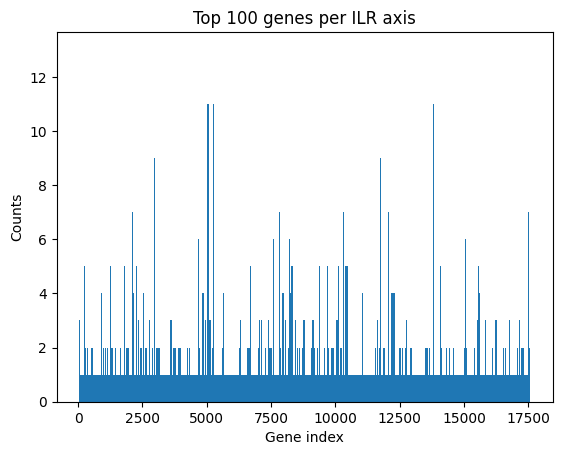

In [238]:
hplot = plt.hist(topgenes_idx.ravel(), bins = np.unique(topgenes_idx.ravel()))
plt.ylabel("Counts")
plt.xlabel("Gene index")
plt.title(f"Top {n_features} genes per ILR axis")

In [206]:
counts_quantiles = np.quantile(counts, q = [0.5, 0.75, 0.95])
counts_quantiles

array([1., 2., 5.])

In [324]:
# find genes with counts >= 3

highfreq_topgenes_idx = unique_values[counts>=counts_quantiles[-1]]
highfreq_topgenes_idx = unique_values[counts>=6]

In [325]:
len(highfreq_topgenes_idx)

31

In [326]:
# check and filter only gene indices rather than covariates
highfreq_topgenes_idx = highfreq_topgenes_idx[highfreq_topgenes_idx < Xs_pseudobulk_train.shape[1]]

In [327]:
# standardize gene
scaler_gene = StandardScaler()
Xs_pseudobulk_train_scaled = scaler_gene.fit_transform(Xs_pseudobulk_train.toarray())
Xs_pseudobulk_test_scaled = scaler_gene.transform(Xs_pseudobulk_test.toarray())

# do pseudobulk variance at sample level
Xs_train_var = X_var_matrix(Xs_train_log)

Xs_pseudobulk_train_var = do_pseudobulk(G, Xs_train_var)
Xs_pseudobulk_train_var = Xs_pseudobulk_train_var / np.clip(n_cells_per_group_train, 1, None)

scaler_var = StandardScaler()
Xs_pseudobulk_train_var_scaled = scaler_var.fit_transform(Xs_pseudobulk_train_var)  # Fit and transform train

Xs_test_var = X_var_matrix(Xs_test_log)
Xs_pseudobulk_test_var = do_pseudobulk(G_test, Xs_test_var)
Xs_pseudobulk_test_var = Xs_pseudobulk_test_var / np.clip(n_cells_per_group_test, 1, None)
Xs_pseudobulk_test_var_scaled = scaler_var.transform(Xs_pseudobulk_test_var)

In [328]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score

def partition_within_between_variance_test(ilr_axis_train, ilr_axis_test,
                                           gene_means_train, gene_means_test,
                                           gene_vars_train, gene_vars_test):
    """
    Variance partition with proper train/test split
    
    Parameters:
    -----------
    ilr_axis_train/test : array (n_samples,)
    gene_means_train/test : array (n_samples, n_genes)
    gene_vars_train/test : array (n_samples, n_genes)
    
    Returns:
    --------
    dict with variance components evaluated on TEST set
    """
    
    # Add intercept
    X_means_train = sm.add_constant(gene_means_train)
    X_means_test = sm.add_constant(gene_means_test)
    # print(f"Shape of X_means_train is: {X_means_train.shape}")
    # print(f"Shape of X_means_test is: {X_means_test.shape}")


    X_vars_train = sm.add_constant(gene_vars_train)
    X_vars_test = sm.add_constant(gene_vars_test)
    # print(f"Shape of X_vars_train is: {X_vars_}")
    
    X_both_train = sm.add_constant(np.hstack([gene_means_train, gene_vars_train]))
    X_both_test = sm.add_constant(np.hstack([gene_means_test, gene_vars_test]))
    
    # Model 1: Between-sample only (gene means)
    model_between = sm.OLS(ilr_axis_train, X_means_train).fit()
    pred_between_test = model_between.predict(X_means_test)
    r2_between = r2_score(ilr_axis_test, pred_between_test)
    
    # Model 2: Within-sample only (gene variances)
    model_within = sm.OLS(ilr_axis_train, X_vars_train).fit()
    pred_within_test = model_within.predict(X_vars_test)
    r2_within = r2_score(ilr_axis_test, pred_within_test)
    
    # Model 3: Full model (both)
    model_full = sm.OLS(ilr_axis_train, X_both_train).fit()
    pred_full_test = model_full.predict(X_both_test)
    r2_full = r2_score(ilr_axis_test, pred_full_test)
    
    # Variance partitioning on TEST performance
    unique_between = r2_full - r2_within
    unique_within = r2_full - r2_between
    shared = r2_between + r2_within - r2_full
    unexplained = 1 - r2_full
    
    return {
        'r2_between_only': r2_between,
        'r2_within_only': r2_within,
        'r2_full': r2_full,
        'unique_between': unique_between,
        'unique_within': unique_within,
        'shared': shared,
        'unexplained': unexplained,
        'model_between': model_between,
        'model_within': model_within,
        'model_full': model_full
    }


In [339]:
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

def variance_partition_means_only(ilr_axis_train, ilr_axis_test,
                                  gene_means_train, gene_means_test,
                                  ):
    """
    Simplified variance partition using ONLY gene means
    Uses ridge to select top genes, then OLS for evaluation
    """
    # Step 3: Add intercept and fit OLS
    X_train = sm.add_constant(gene_means_train)
    X_test = sm.add_constant(gene_means_test)
    
    # Fit model on training data
    model = sm.OLS(ilr_axis_train, X_train).fit()
    
    # Evaluate on test data
    pred_test = model.predict(X_test)
    r2_test = r2_score(ilr_axis_test, pred_test)
    
    # Training R² for comparison
    r2_train = model.rsquared
    
    return {
        'r2_test': r2_test,
        'r2_train': r2_train,
        'model': model
    }


In [330]:
# remove constant genes

gene_means_train = Xs_pseudobulk_train_scaled[:, highfreq_topgenes_idx]
gene_means_test = Xs_pseudobulk_test_scaled[:, highfreq_topgenes_idx]
gene_vars_train = Xs_pseudobulk_train_var_scaled[:, highfreq_topgenes_idx]
gene_vars_test = Xs_pseudobulk_test_var_scaled[:, highfreq_topgenes_idx]

# Check for columns with zero variance
train_std = np.std(gene_means_train, axis=0)
test_std = np.std(gene_means_test, axis=0)

print(f"Genes with zero variance in TRAIN: {np.sum(train_std == 0)}")
print(f"Genes with zero variance in TEST: {np.sum(test_std == 0)}")

train_vars_std = np.std(gene_vars_train, axis=0)
test_vars_std = np.std(gene_vars_test, axis=0)

print(f"Genes with zero variance in TRAIN: {np.sum(train_vars_std == 0)}")
print(f"Genes with zero variance in TEST: {np.sum(test_vars_std == 0)}")

thres = 1e-3
mask = (test_std > thres) & (train_std > thres) & (train_vars_std > thres) & (test_vars_std > thres)

highfreq_topgenes_idx = highfreq_topgenes_idx[mask]

Genes with zero variance in TRAIN: 0
Genes with zero variance in TEST: 0
Genes with zero variance in TRAIN: 0
Genes with zero variance in TEST: 5


In [347]:
len(highfreq_topgenes_idx)

20

In [335]:
# for individual gene
partition_within_between_variance_test(ilr_axis_train = Y_train[:, i],
                                       ilr_axis_test = Y_test[:, i],
                                       gene_means_train = Xs_pseudobulk_train_scaled[:, [highfreq_topgenes_idx[1]]], 
                                       gene_means_test = Xs_pseudobulk_test_scaled[:, [highfreq_topgenes_idx[1]]],
                                       gene_vars_train = Xs_pseudobulk_train_var_scaled[:, [highfreq_topgenes_idx[1]]], 
                                       gene_vars_test = Xs_pseudobulk_test_var_scaled[:, [highfreq_topgenes_idx[1]]])

{'r2_between_only': -0.03335648123361423,
 'r2_within_only': -0.03183925951969169,
 'r2_full': -0.7503985208685533,
 'unique_between': -0.7185592613488616,
 'unique_within': -0.7170420396349391,
 'shared': 0.6852027801152474,
 'unexplained': 1.7503985208685533,
 'model_between': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1486505650>,
 'model_within': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1486506110>,
 'model_full': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1486506750>}

In [337]:
# for all genes
partition_within_between_variance_test(ilr_axis_train = Y_train[:, i],
                                       ilr_axis_test = Y_test[:, i],
                                       gene_means_train = Xs_pseudobulk_train_scaled[:, highfreq_topgenes_idx[:2]], 
                                       gene_means_test = Xs_pseudobulk_test_scaled[:, highfreq_topgenes_idx[:2]],
                                       gene_vars_train = Xs_pseudobulk_train_var_scaled[:, highfreq_topgenes_idx[:2]], 
                                       gene_vars_test = Xs_pseudobulk_test_var_scaled[:, highfreq_topgenes_idx[:2]])

{'r2_between_only': -0.11270426107668152,
 'r2_within_only': -0.03479195884506159,
 'r2_full': -0.9003524255449742,
 'unique_between': -0.8655604666999126,
 'unique_within': -0.7876481644682927,
 'shared': 0.7528562056232311,
 'unexplained': 1.9003524255449742,
 'model_between': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1486544110>,
 'model_within': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1486544c90>,
 'model_full': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1486544e50>}

In [349]:
variance_partition_means_only(ilr_axis_train =  Y_train[:, i],
                              ilr_axis_test =  Y_test[:, i],
                              gene_means_train = Xs_pseudobulk_train_scaled[:, highfreq_topgenes_idx],
                              gene_means_test = Xs_pseudobulk_test_scaled[:, highfreq_topgenes_idx],
                              )

{'r2_test': -4.620283854731676,
 'r2_train': 0.43218658964613454,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f14865501d0>}

In [388]:
# remove constant genes

gene_means_train = Xs_pseudobulk_train_scaled[:, top_genes_norm_idx]
gene_means_test = Xs_pseudobulk_test_scaled[:, top_genes_norm_idx]
gene_vars_train = Xs_pseudobulk_train_var_scaled[:, top_genes_norm_idx]
gene_vars_test = Xs_pseudobulk_test_var_scaled[:, top_genes_norm_idx]

thres = 1e-3

# Check for columns with zero variance
train_std = np.std(gene_means_train, axis=0)
test_std = np.std(gene_means_test, axis=0)

print(f"Genes with zero variance in TRAIN: {np.sum(train_std <= thres)}")
print(f"Genes with zero variance in TEST: {np.sum(test_std <= thres)}")

train_vars_std = np.std(gene_vars_train, axis=0)
test_vars_std = np.std(gene_vars_test, axis=0)

print(f"Genes with zero variance in TRAIN: {np.sum(train_vars_std <= thres)}")
print(f"Genes with zero variance in TEST: {np.sum(test_vars_std <= thres)}")


mask = (test_std >= thres) & (train_std >= thres) & (train_vars_std >= thres) & (test_vars_std >= thres)

top_genes_norm_idx = top_genes_norm_idx[mask]

print(f"Total number of genes: {len(top_genes_norm_idx)}")

Genes with zero variance in TRAIN: 0
Genes with zero variance in TEST: 0
Genes with zero variance in TRAIN: 0
Genes with zero variance in TEST: 0
Total number of genes: 73


In [390]:


variance_partition_means_only(ilr_axis_train =  Y_train[:, i],
                              ilr_axis_test =  Y_test[:, i],
                              gene_means_train = Xs_pseudobulk_train_scaled[:, top_genes_norm_idx],
                              gene_means_test = Xs_pseudobulk_test_scaled[:, top_genes_norm_idx],
                              )


{'r2_test': -146.81066846406551,
 'r2_train': 0.6596566855937183,
 'model': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x7f1573e6e950>}

In [33]:
# # try kernel ridge

# from sklearn.kernel_ridge import KernelRidge
# from sklearn.model_selection import GridSearchCV
# from sklearn.multioutput import MultiOutputRegressor

# # Grid search for optimal parameters with MultiOutputRegressor
# param_grid_krr = {
#     'estimator__alpha': [0.1, 1.0, 10.0, 100.0],  # regularization strength
#     'estimator__gamma': [0.001, 0.01, 0.1, 1.0]   # RBF kernel bandwidth
# }

# # Wrap KernelRidge in MultiOutputRegressor
# multi_krr = MultiOutputRegressor(KernelRidge(kernel='rbf'))

# # GridSearchCV on the multi-output wrapper
# krr_cv = GridSearchCV(multi_krr, param_grid_krr, 
#                       cv=5, scoring='neg_mean_squared_error',
#                       verbose=2, n_jobs=-1)

# krr_cv.fit(X_train_scaled, Y_train)
# print(f"Best params: {krr_cv.best_params_}")

# # Get predictions
# Y_pred = krr_cv.predict(X_test_scaled)

# # Access the best estimator
# best_model = krr_cv.best_estimator_

# # Or you can use krr_cv.predict() directly (it uses best_estimator_ internally)
# Y_pred = krr_cv.predict(X_test_scaled)

In [34]:
# cor_list_KRR = [sp.stats.spearmanr(Y_pred[:, i], Y_test[:, i])[0] for i in np.arange(Y_test.shape[1])]
# cor_list_KRR

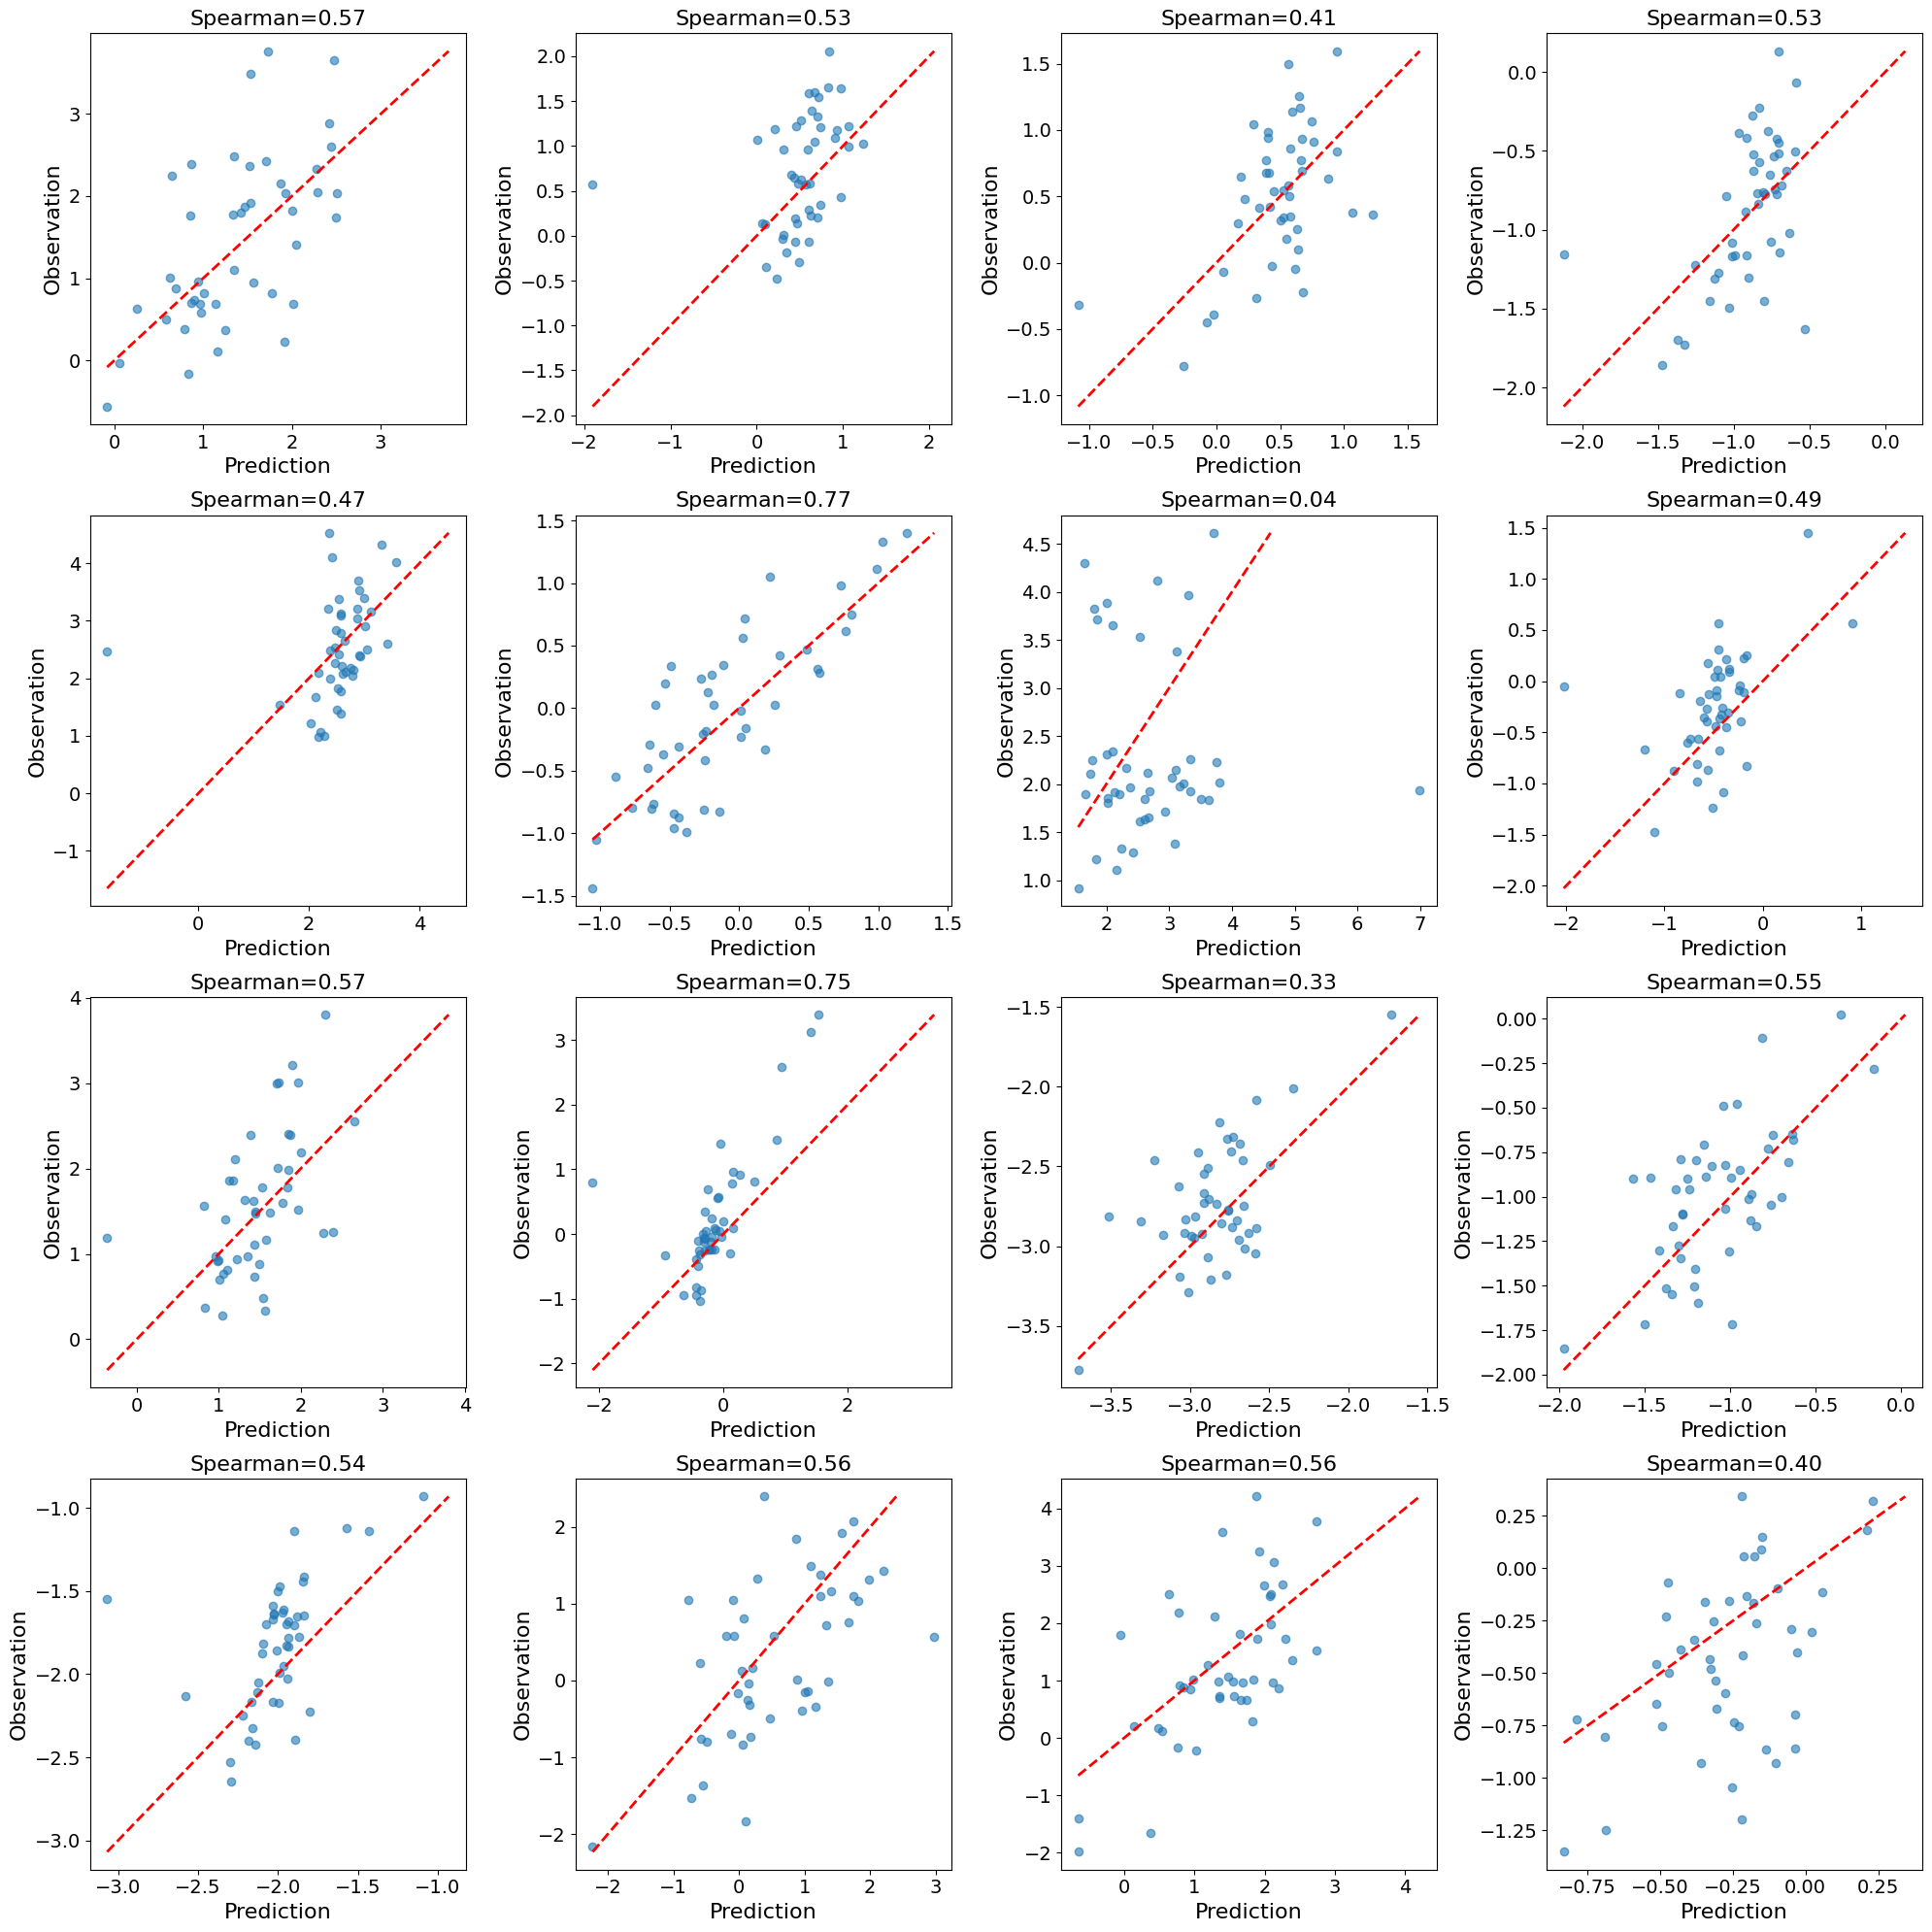

In [44]:
import matplotlib.pyplot as plt

ncols = 4
nrows = round(Y_test.shape[1]/ncols) 

# cor_list_regression = [np.corrcoef(Y_pred_test[:, i], Y_test[:, i])[0][1] for i in np.arange(Y_test.shape[1])]
cor_list_regression = [sp.stats.spearmanr(Y_pred_test[:, i], Y_test[:, i])[0] for i in np.arange(Y_test.shape[1])]

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(Y_test.shape[1]):
    axs[i].scatter(Y_pred_test[:,i].ravel(), Y_test[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction', fontsize = 16)
    axs[i].set_ylabel('Observation', fontsize = 16)
    axs[i].tick_params(axis = 'both', labelsize = 14)
    # axs[i].set_xscale('log')
    # axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}")
    # axs[i].set_title(f"Pearson={cor_list_regression[i]:.2f}", fontsize = 16)
    axs[i].set_title(f"Spearman={cor_list_regression[i]:.2f}", fontsize = 16)

    min_val = min(Y_pred_test[:, i].min(), Y_pred_test[:, i].min())
    max_val = max(Y_test[:, i].max(), Y_test[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

Text(0, 0.5, 'MLP_1L')

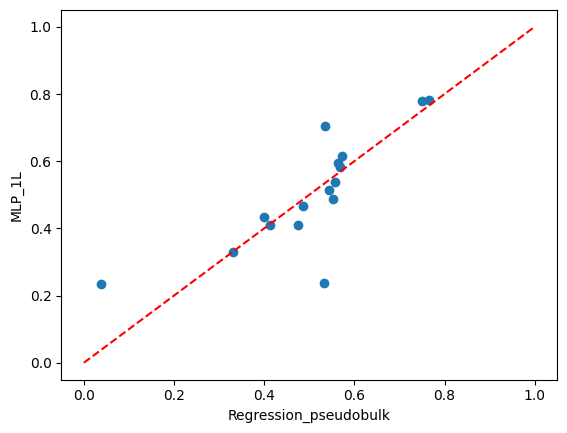

In [36]:
plt.scatter(cor_list_regression, cor_list)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L')

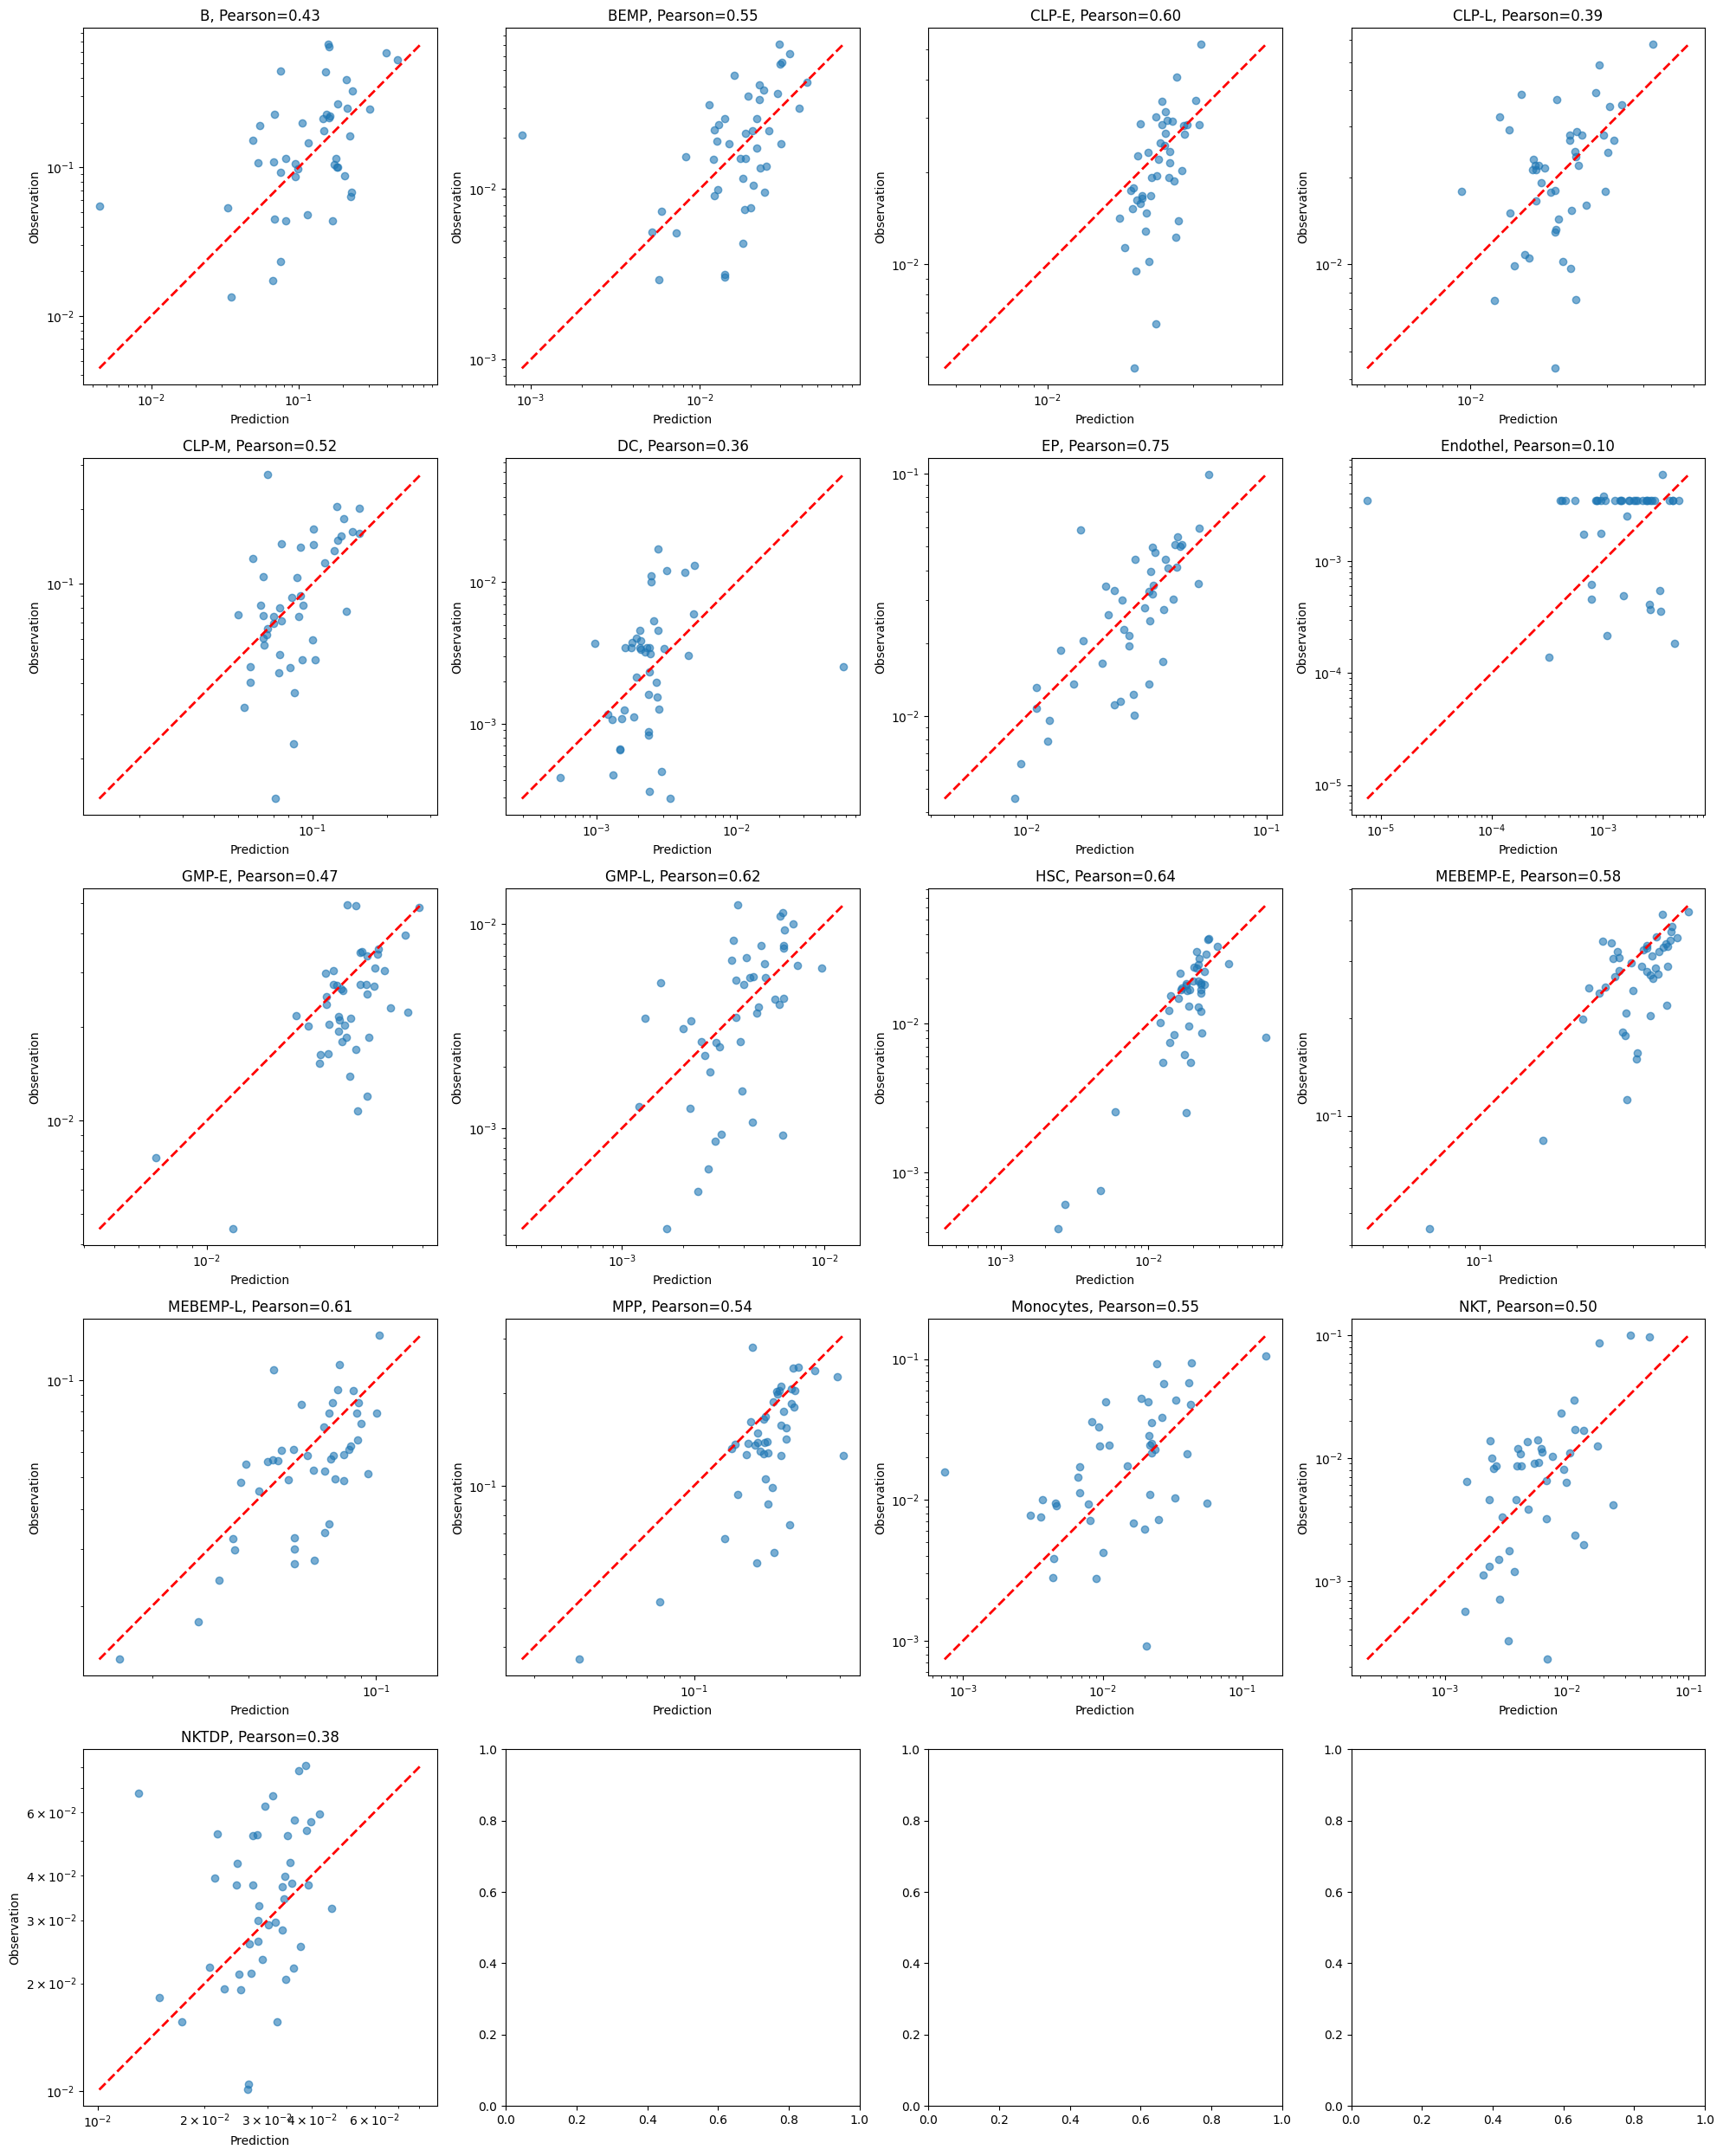

In [37]:
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr

ncols = 4
nrows = round(targets.shape[1]/ncols) + 1

ct_preds = ilr_inv(Y_pred_test)
ct_obs = ilr_inv(Y_test)

# ct_cor_regression = [np.corrcoef(ct_preds[:, i], ct_obs[:, i])[0][1] for i in range(cell_type_proportions_df.shape[1])]

ct_cor_regression = [sp.stats.spearmanr(ct_preds[:, i], ct_obs[:, i])[0] for i in range(cell_type_proportions_df.shape[1])]

# manual check
# row_id, col_id = np.where(ct_preds < 1e-3)
# ct_cor_regression = []
# for i in range(cell_type_proportions_df.shape[1]):
#     id_filtered = np.setdiff1d(np.arange(ct_obs.shape[0]), row_id[col_id == i])
#     ct_cor_regression.append(sp.stats.spearmanr(ct_preds[id_filtered, i], ct_obs[id_filtered, i])[0])

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(cell_type_proportions_df.shape[1]):
    axs[i].scatter(ct_preds[:, i].ravel(), ct_obs[:, i].ravel(), alpha = 0.6)
    # axs[i].scatter(ct_preds[id_filtered, i].ravel(), ct_obs[id_filtered, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction')
    axs[i].set_ylabel('Observation')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Pearson={ct_cor_regression[i]:.2f}")

    min_val = min(ct_preds[:, i].min(), ct_obs[:, i].min())
    max_val = max(ct_preds[:, i].max(), ct_obs[:, i].max())

    # min_val = min(ct_preds[id_filtered, i].min(), ct_obs[id_filtered, i].min())
    # max_val = max(ct_preds[id_filtered, i].max(), ct_obs[id_filtered, i].max())


    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

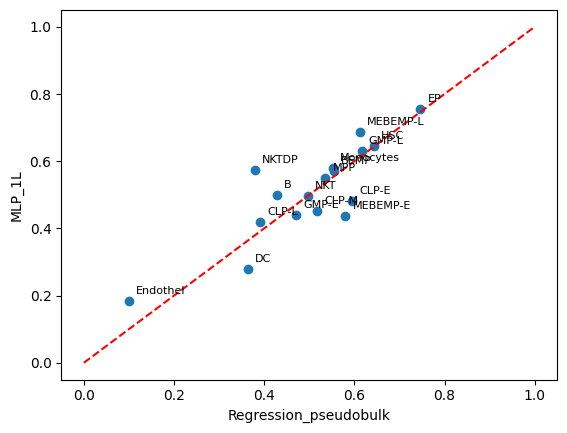

In [38]:
plt.scatter(ct_cor_regression, ct_cor)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L')

# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_regression[i], ct_cor[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)
    

# initialize weights with ridge coefficients

In [ ]:
def initialize_response_pc_only(model, Y_train, n_features, n_outputs, hidden_dim=512, seed=0):
    """
    Simplest: just align second layer with response PCs
    Ignore ridge coefficients entirely
    """
    # Response PCA
    Y_centered = Y_train - Y_train.mean(axis=0)
    U_y, S_y, Vt_y = np.linalg.svd(Y_centered.T, full_matrices=False)
    
    k = min(hidden_dim, n_outputs)
    
    if seed is not None:
        np.random.seed(seed)
    
    # First layer: Random (or He initialization)
    W1 = np.random.randn(hidden_dim, n_features) * np.sqrt(2.0 / n_features)
    
    # Second layer: Align with response PCs
    W2 = np.zeros((n_outputs, hidden_dim))
    
    # First k neurons aligned with top k PCs
    pc_indices = np.random.choice(hidden_dim, size=k, replace=False)
    for i, idx in enumerate(pc_indices):
        if i < len(S_y):
            W2[:, idx] = U_y[:, i] * np.sqrt(S_y[i])  # Scale by singular value
    
    # Remaining neurons: random
    remaining = np.setdiff1d(np.arange(hidden_dim), pc_indices)
    W2[:, remaining] = np.random.randn(n_outputs, len(remaining)) * 0.1
    
    with torch.no_grad():
        model.cell_predictor.network[0].weight.data.copy_(torch.tensor(W1, dtype=torch.float32))
        model.cell_predictor.network[0].bias.data.zero_()
        
        model.cell_predictor.network[-1].weight.data.copy_(torch.tensor(W2, dtype=torch.float32))
        model.cell_predictor.network[-1].bias.data.copy_(torch.tensor(Y_train.mean(axis=0), dtype=torch.float32))


In [ ]:
# use low rank of ridge regression as initialization

import torch
import numpy as np
from regression.neural_network import Preprocessor, CompositionModel, Trainer
from regression.neural_network.data_utils import (
    collate_samples_compact, compute_cellwise_stats, 
    evaluate_on_loader, build_datasets_from_indices
    )

from regression.neural_network import build_loaders
from regression.neural_network.dataclass_models import DataInputs, ModelHyperparams, TrainSetup


def initialize_factorized_ridge(model, ridge_coef, n_features, n_outputs, hidden_dim=512, seed = 0):
    """
    Factorize ridge: W_ridge ≈ W1^T @ W2^T
    where W1: (n_genes, hidden_dim), W2: (hidden_dim, 16)
    """
    # n_genes, n_outputs = ridge_coef.shape
    
    # SVD: ridge_coef = U @ S @ V^T
    U, S, Vt = np.linalg.svd(ridge_coef, full_matrices=False)
    # U: (n_genes, 16), S: (16,), Vt: (16, 16)
    
    # Expand to hidden_dim by padding with random features
    k = min(hidden_dim, len(S))

    if seed is not None:
        np.random.seed(seed)

    # First layer: gene → hidden (expand U to hidden_dim)
    # W1 = np.zeros((hidden_dim, n_features))
    # W1[:k, :] = (U[:, :k] * np.sqrt(S[:k])).T + np.random.randn(k, n_features) * 0.01 # Load top components with ridge structure
    # W1[:len(S), :] = (np.sqrt(S)[:, None] * U.T)  # (k, n_genes)
    # Add random features for remaining dimensions
    # W1[k:, :] = np.random.randn(hidden_dim - k, n_features) * 0.05
    # W1[k:, :] = np.random.uniform(low = -1e-3, high = 1e-3, size = (hidden_dim - k, n_features))
    # W1[k:, :] = np.random.uniform(low = -1e-2, high = 1e-2, size = (hidden_dim - k, n_features))
    # W1[k:, :] = np.random.uniform(low = -1e-1, high = 1e-1, size = (hidden_dim - k, n_features))

    # Randomly pick k rows in W1 to assign ridge components
    ridge_indices = np.random.choice(hidden_dim, size=k, replace=False)
    remaining_indices = np.setdiff1d(np.arange(hidden_dim), ridge_indices)

    W1 = np.zeros((hidden_dim, n_features))
    # Assign ridge components to random positions
    W1[ridge_indices, :] = (U[:, :k] * np.sqrt(S[:k])).T + np.random.randn(k, n_features) * 0.01
    # Fill remaining with random noise
    W1[remaining_indices, :] = np.random.randn(hidden_dim - k, n_features) * 0.1


    # Second layer: hidden → output
    # W2 = np.zeros((n_outputs, hidden_dim))
    # W2[:, :k] = (np.sqrt(S[:k]) * Vt[:k, :]).T  + np.random.randn(n_outputs, k) * 0.05 # Match the ridge structure
    # W2[:, k:] = np.random.randn(n_outputs, hidden_dim - k) * 0.01
    # W2[:, k:] = np.random.uniform(low = -1e-3, high = 1e-3, size = (n_outputs, hidden_dim - k))
    # W2[:, k:] = np.random.uniform(low = -1e-1, high = 1e-1, size = (n_outputs, hidden_dim - k))

    # Second layer: Match the random assignment
    W2 = np.zeros((n_outputs, hidden_dim))
    W2[:, ridge_indices] = (np.sqrt(S[:k]) * Vt[:k, :]).T + np.random.randn(n_outputs, k) * 0.01
    W2[:, remaining_indices] = np.random.randn(n_outputs, hidden_dim - k) * 0.1

    
    with torch.no_grad():
        model.cell_predictor.network[0].weight.data.copy_(torch.tensor(W1, dtype=torch.float32))
        # model.cell_predictor.network[0].bias.data.zero_()
        # model.cell_predictor.network[0].bias.data.uniform_(-1e-3, 1e-3)        
        # model.cell_predictor.network[0].bias.data.uniform_(-1e-2, 1e-2)        
        model.cell_predictor.network[0].bias.data.uniform_(-1e-1, 1e-1)        

        model.cell_predictor.network[-1].weight.data.copy_(torch.tensor(W2, dtype=torch.float32))
        # model.cell_predictor.network[-1].bias.data.zero_()
        # model.cell_predictor.network[-1].bias.data.uniform_(-1e-3, 1e-3)        
        # model.cell_predictor.network[-1].bias.data.uniform_(-1e-2, 1e-2)        
        model.cell_predictor.network[-1].bias.data.uniform_(-1e-1, 1e-1)        


                
from typing import Callable, Union, Any, Dict

def run_one_fold_init_regression(data: DataInputs, 
                                 hyperparams: ModelHyperparams, 
                                 setup: TrainSetup, 
                                 fold: int, 
                                 fold_idxs: Dict[str, Any],
                                 W_regression: np.ndarray,
                                 n_covariates: int,
                                 seed: int) -> Dict[str, Any]:
    '''
    DataInputs: a DataClass storing data for training
    hyperparams: a DataClass storing MLP architecture parameters
    setup: a DataClass storing parameters to run the MLP
    fold: the fold ordering (e.g., 0, 1, 2)
    fold_idxs: storing indices of samples for training, validating and testing
    '''
    
    # Unpack for clarity 
    Xs_raw = data.Xs_raw
    Z = data.Z
    Y_imp_ilr = data.Y_imp_ilr
    cell_type_proportions_df = data.cell_type_proportions_df
    
    hidden_features = hyperparams.hidden_features
    num_hidden_layers = hyperparams.num_hidden_layers
    activation = hyperparams.activation
    dropout = hyperparams.dropout
    batch_norm = hyperparams.batch_norm
    bias = hyperparams.bias
    scaling_factor = hyperparams.scaling_factor
    method = hyperparams.method
    layer_norm=hyperparams.layer_norm
    activation_type=hyperparams.activation_type #still factory
    loss_fn=hyperparams.loss_fn(**hyperparams.loss_fn_kwargs) #instantiate the factory here

    
    batch_size = setup.batch_size
    device = setup.device
    epochs = setup.epochs
    lr = setup.lr
    weight_decay = setup.weight_decay
    return_compositions = setup.return_compositions
    use_lr_scheduler = setup.use_lr_scheduler

    # Build datasets for this fold
    datasets, extras = build_datasets_from_indices(
        method=method,
        Xs_raw=Xs_raw,
        Z=Z,
        Y_imp_ilr=Y_imp_ilr,
        cell_type_proportions_df=cell_type_proportions_df,
        indices=fold_idxs,
        dtype=torch.float32,
    )
    # Build loaders (use your compact collate)
    loaders = build_loaders(datasets, batch_size=batch_size, num_workers=0, pin_memory=True, collate_fn=collate_samples_compact)
    loader = loaders["train"]
    loader_val = loaders["val"]
    loader_test = loaders["test"]
    
    # Recompute training-only stats per fold
    gene_mean, gene_std = compute_cellwise_stats(loader, device="cpu")
    tol = 1e-6
    gene_mask = (gene_std > tol)
    G_kept = int(gene_mask.sum().item())
    C = np.asarray(Z).shape[1]
    in_features = G_kept + C
    out_features = (Y_imp_ilr.shape[1] if method.endswith("ilr") else np.asarray(cell_type_proportions_df).shape[1])
    age_column_id = Z.columns.tolist().index('ages')
    train_idx = fold_idxs['train']
    age_mean = Z.iloc[train_idx]['ages'].mean()
    age_std = Z.iloc[train_idx]['ages'].std()
    
    # Build preprocessor and model for this fold
    pre = Preprocessor(gene_mask=gene_mask.to(device=device),
                       gene_mean=gene_mean.to(device=device),
                       gene_std=gene_std.to(device=device),
                       cont_cov_mask=age_column_id,
                       cov_mean=torch.tensor(age_mean).to(device=device),
                       cov_std=torch.tensor(age_std).to(device=device),
                       scaling_factor=scaling_factor,
                       normalize=True)
   
    model = CompositionModel(
        in_features=in_features,
        out_features=out_features,
        method=method,
        aggregator_mode="mean",
        preprocessor=pre,
        hidden_features=hidden_features, 
        num_hidden_layers=num_hidden_layers, 
        activation=activation,
        dropout=dropout, 
        batch_norm=batch_norm, 
        bias=bias, 
        dtype=torch.float32,
        layer_norm=layer_norm,
        activation_type=activation_type,
    )
    #initialize with pseudobulk weights
    #last Z.shape[1] is covariates so need to do this to filter out genes
    # W = np.concatenate((W_regression[:-Z.shape[1], :][gene_mask.cpu().numpy(), :], W_regression[-Z.shape[1]:, :]), axis = 0)

    # init_from_W_regression(model, W_regression, n_covariates, gene_mask, b_regression=None)
    # initialize_factorized_ridge(model, W,
    #                             n_features = in_features, 
    #                             n_outputs = out_features,
    #                             hidden_dim = hidden_features,
    #                             seed = seed)

    initialize_response_pc_only(model, Y_imp_ilr[train_idx, :], in_features, out_features, hidden_dim=hidden_features, seed=seed)
    
    # Train on this device
    trainer = Trainer(model, loader, loader_val,
                      lr=lr, weight_decay=weight_decay,
                      epochs=epochs, recenter_y=(method == "ilr_recenter"),
                      device=device, dtype=torch.float32, verbose=False,
                      use_lr_scheduler=use_lr_scheduler,
                      scheduler_name='cosine',
                      loss_fn = loss_fn,
                      )
    trainer.fit()
    # Evaluate on test
    from torch.nn.functional import mse_loss
    test_res = evaluate_on_loader(trainer.model, loader_test, device=trainer.device,
                                  recenter_y=trainer.recenter_y, y_mean=trainer.y_mean,
                                  return_compositions=return_compositions, method=method)
    test_mse = mse_loss(test_res["preds"], test_res["targets"], reduction="mean").item()
    
    # include checking on cell type
    cor_list = []
    rsq_list = []
    if test_res.get("preds_comp") != None and test_res.get("targets_comp") != None:
        preds_ct = test_res["preds_comp"].cpu().numpy()
        targets_ct = test_res["targets_comp"].cpu().numpy()
        cor_list = [np.corrcoef(preds_ct[:, i], targets_ct[:, i], rowvar=False)[0][1] for i in range(preds_ct.shape[1])]
        def rsquared_feature(Y_pred, Y_obs):
            SSE = np.sum((Y_pred - Y_obs)**2, axis = 0)
            SST = np.sum((Y_obs - np.mean(Y_obs, axis = 0))**2, axis = 0)
            return 1 - SSE / SST
        rsq_list = [rsquared_feature(preds_ct[:, i], targets_ct[:, i]) for i in range(preds_ct.shape[1])]

    return {"fold": fold,
            "train_mse_history": list(trainer.train_mse_history),
            "val_mse_history": list(trainer.val_mse_history),
            "test_mse": test_mse,
            "cor_list": cor_list, #for cell type
            "rsq_list": rsq_list,
            "test_res": test_res,
            "trainer": trainer
            }



In [ ]:
import torch.nn as nn
# try relu here 
cfg.hidden_features = 16
cfg.num_hidden_layers = 1
cfg.activation = True
cfg.layer_norm = False
cfg.activation_type = [nn.ReLU]
# cfg.activation_type = [nn.Softplus]

cfg.dropout = 0.5
cfg.batchsize = 8

In [138]:
hyperparams = ModelHyperparams(hidden_features=cfg.hidden_features,
                               num_hidden_layers=cfg.num_hidden_layers,
                               activation=cfg.activation,
                               activation_type=cfg.activation_type, #check to store factory, not instance
                               dropout=cfg.dropout,
                               batch_norm=cfg.batch_norm,
                               bias=bias,
                               scaling_factor=cfg.scaling_factor,
                               method=cfg.method_train,
                               layer_norm=cfg.layer_norm,
                               loss_fn=loss_cls, #check to store factory, not instance
                               loss_fn_kwargs=cfg.loss_kwargs
                               )
setup = TrainSetup(batch_size=cfg.batch_size,
                   device=cfg.device,
                   epochs=cfg.epochs,
                   lr=cfg.lr,
                   weight_decay=cfg.weight_decay,
                   return_compositions=cfg.return_compositions)


In [139]:
hyperparams

ModelHyperparams(hidden_features=16, num_hidden_layers=1, activation=True, dropout=0.5, batch_norm=False, bias=True, scaling_factor=10000.0, method='predict_ilr', layer_norm=False, loss_fn=<class 'torch.nn.modules.loss.MSELoss'>, loss_fn_kwargs={}, activation_type=[<class 'torch.nn.modules.activation.ReLU'>])

In [140]:
W_regression = ridge_cv.coef_.T

print(f'Using fold {fold}')
fold_idxs = folds[fold]
res_init_regression = run_one_fold_init_regression(data, hyperparams, setup, 
                                                   fold=fold, fold_idxs=fold_idxs,
                                                   W_regression = W_regression,
                                                   n_covariates = Z.shape[1],
                                                   seed = fold)


Using fold 2


 12%|█▏        | 121/1000 [03:19<24:10,  1.65s/it]


In [141]:
res_init_regression['trainer'].model

CompositionModel(
  (preprocessor): Preprocessor()
  (aggregator): Aggregator()
  (postprocessor): Postprocessor()
  (cell_predictor): CellPredictor(
    (network): Sequential(
      (0): Linear(in_features=17441, out_features=16, bias=True)
      (1): ReLU()
      (2): Dropout(p=0.5, inplace=False)
      (3): Linear(in_features=16, out_features=16, bias=True)
    )
  )
)

In [154]:
torch.norm(res_init_regression['trainer'].model.cell_predictor.network[0].weight, p = 1,  dim = 0)

tensor([0.6438, 0.5585, 0.7938,  ..., 0.5581, 1.7651, 1.3276], device='cuda:0',
       grad_fn=<LinalgVectorNormBackward0>)

In [157]:
res_init_regression['trainer'].model.cell_predictor.network[-1].weight

Parameter containing:
tensor([[-1.7914e-02, -1.5437e-01, -3.4385e-02,  1.4085e-01, -7.5384e-02,
         -1.8090e-01,  2.7103e-02,  1.9661e-01,  9.0513e-02,  1.6233e-01,
          1.4431e-01,  2.8512e-02, -1.9570e-02,  8.3999e-02,  4.1915e-02,
          8.9307e-02],
        [-8.3409e-03,  5.7018e-02, -6.0000e-02, -6.5411e-02,  1.0870e-02,
          9.0926e-02,  1.2995e-01, -2.5172e-02,  3.6536e-02,  2.6336e-01,
         -9.7970e-02, -5.9146e-02, -7.6785e-02,  6.9341e-02, -9.3577e-03,
          4.4146e-02],
        [-6.7510e-02,  2.0075e-03,  9.4766e-02, -3.1234e-02, -5.4620e-03,
          1.4520e-01,  4.9561e-03, -9.4246e-03, -1.2887e-02,  1.7466e-01,
         -1.0825e-02,  1.3232e-01, -8.7256e-02,  3.0295e-04, -5.0498e-02,
          5.8163e-03],
        [-4.6616e-02, -6.5805e-02, -9.8227e-03, -4.7925e-02, -2.3457e-02,
          1.2892e-01, -5.3719e-02, -7.3575e-02,  5.1384e-02,  1.5181e-01,
         -6.2909e-03, -4.4625e-02, -3.1946e-02, -4.0990e-02, -6.5872e-02,
         -1.1002e-03]

In [142]:
import torch
import numpy as np
from regression.neural_network import Preprocessor, CompositionModel, Trainer
from regression.neural_network.data_utils import (
    collate_samples_compact, compute_cellwise_stats, 
    evaluate_on_loader, build_datasets_from_indices
    )

from regression.neural_network import build_loaders
from regression.neural_network.dataclass_models import DataInputs, ModelHyperparams, TrainSetup


def init_from_W_regression(model, W_regression, n_covariates, gene_mask, b_regression=None, device="cuda", dtype=torch.float32):
    """
    model: CompositionModel with model.cell_predictor.network[0] as nn.Linear(17465->16)
    W_regression: (16, n_genes_total) numpy or torch
    gene_mask: boolean mask (len n_genes_total) or integer indices selecting 17465 genes
    b_regression: optional (16,) bias
    """
    linear = model.cell_predictor.network[0]
    assert isinstance(linear, torch.nn.Linear)

    # the last n_covariates columns are for covariates
    W_genes = torch.as_tensor(W_regression[:, :-n_covariates], dtype=dtype)
    W_genes = W_genes[:, gene_mask]  
    # combine with covariates column
    W = torch.hstack((W_genes, torch.as_tensor(W_regression[:, -n_covariates:], dtype = dtype)))

    if W.shape != linear.weight.shape:
        raise ValueError(f"Shape mismatch: sliced W {tuple(W.shape)} vs layer {tuple(linear.weight.shape)}")

    with torch.no_grad():
        linear.weight.copy_(W.to(device=device))
        if linear.bias is not None:
            if b_regression is None:
                linear.bias.zero_()
            else:
                b = torch.as_tensor(b_regression, dtype=dtype)
                linear.bias.copy_(b.to(device=device))
                
from typing import Callable, Union, Any, Dict

def run_one_fold_init_regression(data: DataInputs, 
                                 hyperparams: ModelHyperparams, 
                                 setup: TrainSetup, 
                                 fold: int, 
                                 fold_idxs: Dict[str, Any],
                                 W_regression: np.ndarray,
                                 n_covariates: int) -> Dict[str, Any]:
    '''
    DataInputs: a DataClass storing data for training
    hyperparams: a DataClass storing MLP architecture parameters
    setup: a DataClass storing parameters to run the MLP
    fold: the fold ordering (e.g., 0, 1, 2)
    fold_idxs: storing indices of samples for training, validating and testing
    '''
    
    # Unpack for clarity 
    Xs_raw = data.Xs_raw
    Z = data.Z
    Y_imp_ilr = data.Y_imp_ilr
    cell_type_proportions_df = data.cell_type_proportions_df
    
    hidden_features = hyperparams.hidden_features
    num_hidden_layers = hyperparams.num_hidden_layers
    activation = hyperparams.activation
    dropout = hyperparams.dropout
    batch_norm = hyperparams.batch_norm
    bias = hyperparams.bias
    scaling_factor = hyperparams.scaling_factor
    method = hyperparams.method
    layer_norm=hyperparams.layer_norm
    activation_type=hyperparams.activation_type #still factory
    loss_fn=hyperparams.loss_fn(**hyperparams.loss_fn_kwargs) #instantiate the factory here

    
    batch_size = setup.batch_size
    device = setup.device
    epochs = setup.epochs
    lr = setup.lr
    weight_decay = setup.weight_decay
    return_compositions = setup.return_compositions
    use_lr_scheduler = setup.use_lr_scheduler

    # Build datasets for this fold
    datasets, extras = build_datasets_from_indices(
        method=method,
        Xs_raw=Xs_raw,
        Z=Z,
        Y_imp_ilr=Y_imp_ilr,
        cell_type_proportions_df=cell_type_proportions_df,
        indices=fold_idxs,
        dtype=torch.float32,
    )
    # Build loaders (use your compact collate)
    loaders = build_loaders(datasets, batch_size=batch_size, num_workers=0, pin_memory=True, collate_fn=collate_samples_compact)
    loader = loaders["train"]
    loader_val = loaders["val"]
    loader_test = loaders["test"]
    
    # Recompute training-only stats per fold
    gene_mean, gene_std = compute_cellwise_stats(loader, device="cpu")
    tol = 1e-6
    gene_mask = (gene_std > tol)
    G_kept = int(gene_mask.sum().item())
    C = np.asarray(Z).shape[1]
    in_features = G_kept + C
    out_features = (Y_imp_ilr.shape[1] if method.endswith("ilr") else np.asarray(cell_type_proportions_df).shape[1])
    age_column_id = Z.columns.tolist().index('ages')
    train_idx = fold_idxs['train']
    age_mean = Z.iloc[train_idx]['ages'].mean()
    age_std = Z.iloc[train_idx]['ages'].std()
    
    # Build preprocessor and model for this fold
    pre = Preprocessor(gene_mask=gene_mask.to(device=device),
                       gene_mean=gene_mean.to(device=device),
                       gene_std=gene_std.to(device=device),
                       cont_cov_mask=age_column_id,
                       cov_mean=torch.tensor(age_mean).to(device=device),
                       cov_std=torch.tensor(age_std).to(device=device),
                       scaling_factor=scaling_factor,
                       normalize=True)
   
    model = CompositionModel(
        in_features=in_features,
        out_features=out_features,
        method=method,
        aggregator_mode="mean",
        preprocessor=pre,
        hidden_features=hidden_features, 
        num_hidden_layers=num_hidden_layers, 
        activation=activation,
        dropout=dropout, 
        batch_norm=batch_norm, 
        bias=bias, 
        dtype=torch.float32,
        layer_norm=layer_norm,
        activation_type=activation_type,
    )
    #initialize with pseudobulk weights
    init_from_W_regression(model, W_regression, n_covariates, gene_mask, b_regression=None)

    # Train on this device
    trainer = Trainer(model, loader, loader_val,
                      lr=lr, weight_decay=weight_decay,
                      epochs=epochs, recenter_y=(method == "ilr_recenter"),
                      device=device, dtype=torch.float32, verbose=False,
                      use_lr_scheduler=use_lr_scheduler,
                      scheduler_name='cosine',
                      loss_fn = loss_fn,
                      )
    trainer.fit()
    # Evaluate on test
    from torch.nn.functional import mse_loss
    test_res = evaluate_on_loader(trainer.model, loader_test, device=trainer.device,
                                  recenter_y=trainer.recenter_y, y_mean=trainer.y_mean,
                                  return_compositions=return_compositions, method=method)
    test_mse = mse_loss(test_res["preds"], test_res["targets"], reduction="mean").item()
    
    # include checking on cell type
    cor_list = []
    rsq_list = []
    if test_res.get("preds_comp") != None and test_res.get("targets_comp") != None:
        preds_ct = test_res["preds_comp"].cpu().numpy()
        targets_ct = test_res["targets_comp"].cpu().numpy()
        cor_list = [np.corrcoef(preds_ct[:, i], targets_ct[:, i], rowvar=False)[0][1] for i in range(preds_ct.shape[1])]
        def rsquared_feature(Y_pred, Y_obs):
            SSE = np.sum((Y_pred - Y_obs)**2, axis = 0)
            SST = np.sum((Y_obs - np.mean(Y_obs, axis = 0))**2, axis = 0)
            return 1 - SSE / SST
        rsq_list = [rsquared_feature(preds_ct[:, i], targets_ct[:, i]) for i in range(preds_ct.shape[1])]

    return {"fold": fold,
            "train_mse_history": list(trainer.train_mse_history),
            "val_mse_history": list(trainer.val_mse_history),
            "test_mse": test_mse,
            "cor_list": cor_list, #for cell type
            "rsq_list": rsq_list,
            "test_res": test_res,
            "trainer": trainer
            }


In [143]:

# # fold = 0
# fold_idxs = folds[fold]

# res_init_regression = run_one_fold_init_regression(data, hyperparams, setup, 
#                                                    fold=fold, fold_idxs=fold_idxs,
#                                                    W_regression = W_regression.T,
#                                                    n_covariates = Z.shape[1])


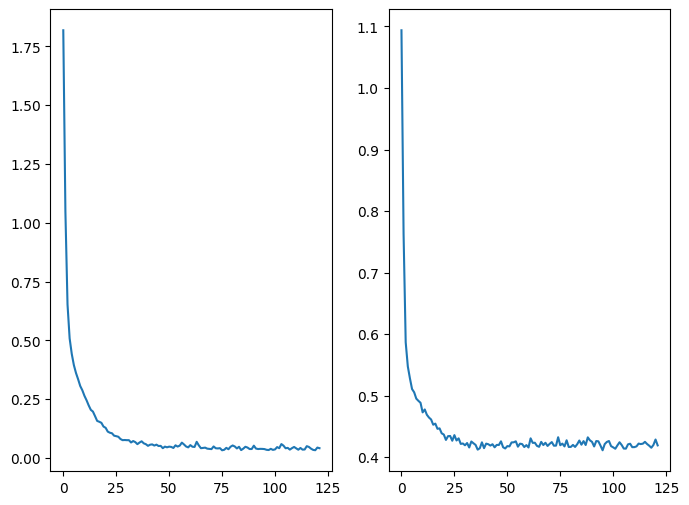

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))
plt.subplot(1,2,1)
plt.plot(res_init_regression['train_mse_history'])
plt.subplot(1,2,2)
plt.plot(res_init_regression['val_mse_history'])

In [145]:
results = res_init_regression['test_res']
preds = results["preds"]             # (S_test, T) aligned with dataset_test indices
targets = results["targets"]         # (S_test, T)
ct_cor_list = res_init_regression['cor_list']

from scipy.stats import pearsonr, spearmanr
# cor_list_init_regression = [pearsonr(preds[:, i], targets[:, i])[0] for i in np.arange(targets.shape[1])]
cor_list_init_regression = [spearmanr(preds[:, i], targets[:, i])[0] for i in np.arange(targets.shape[1])]


Text(0, 0.5, 'MLP_1L_init_regression')

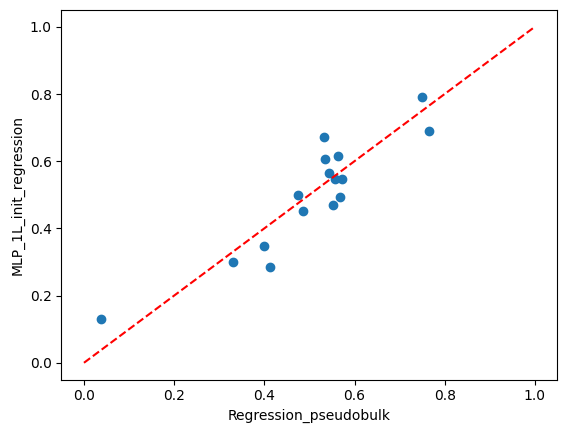

In [146]:
plt.scatter(cor_list_regression, cor_list_init_regression)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L_init_regression')

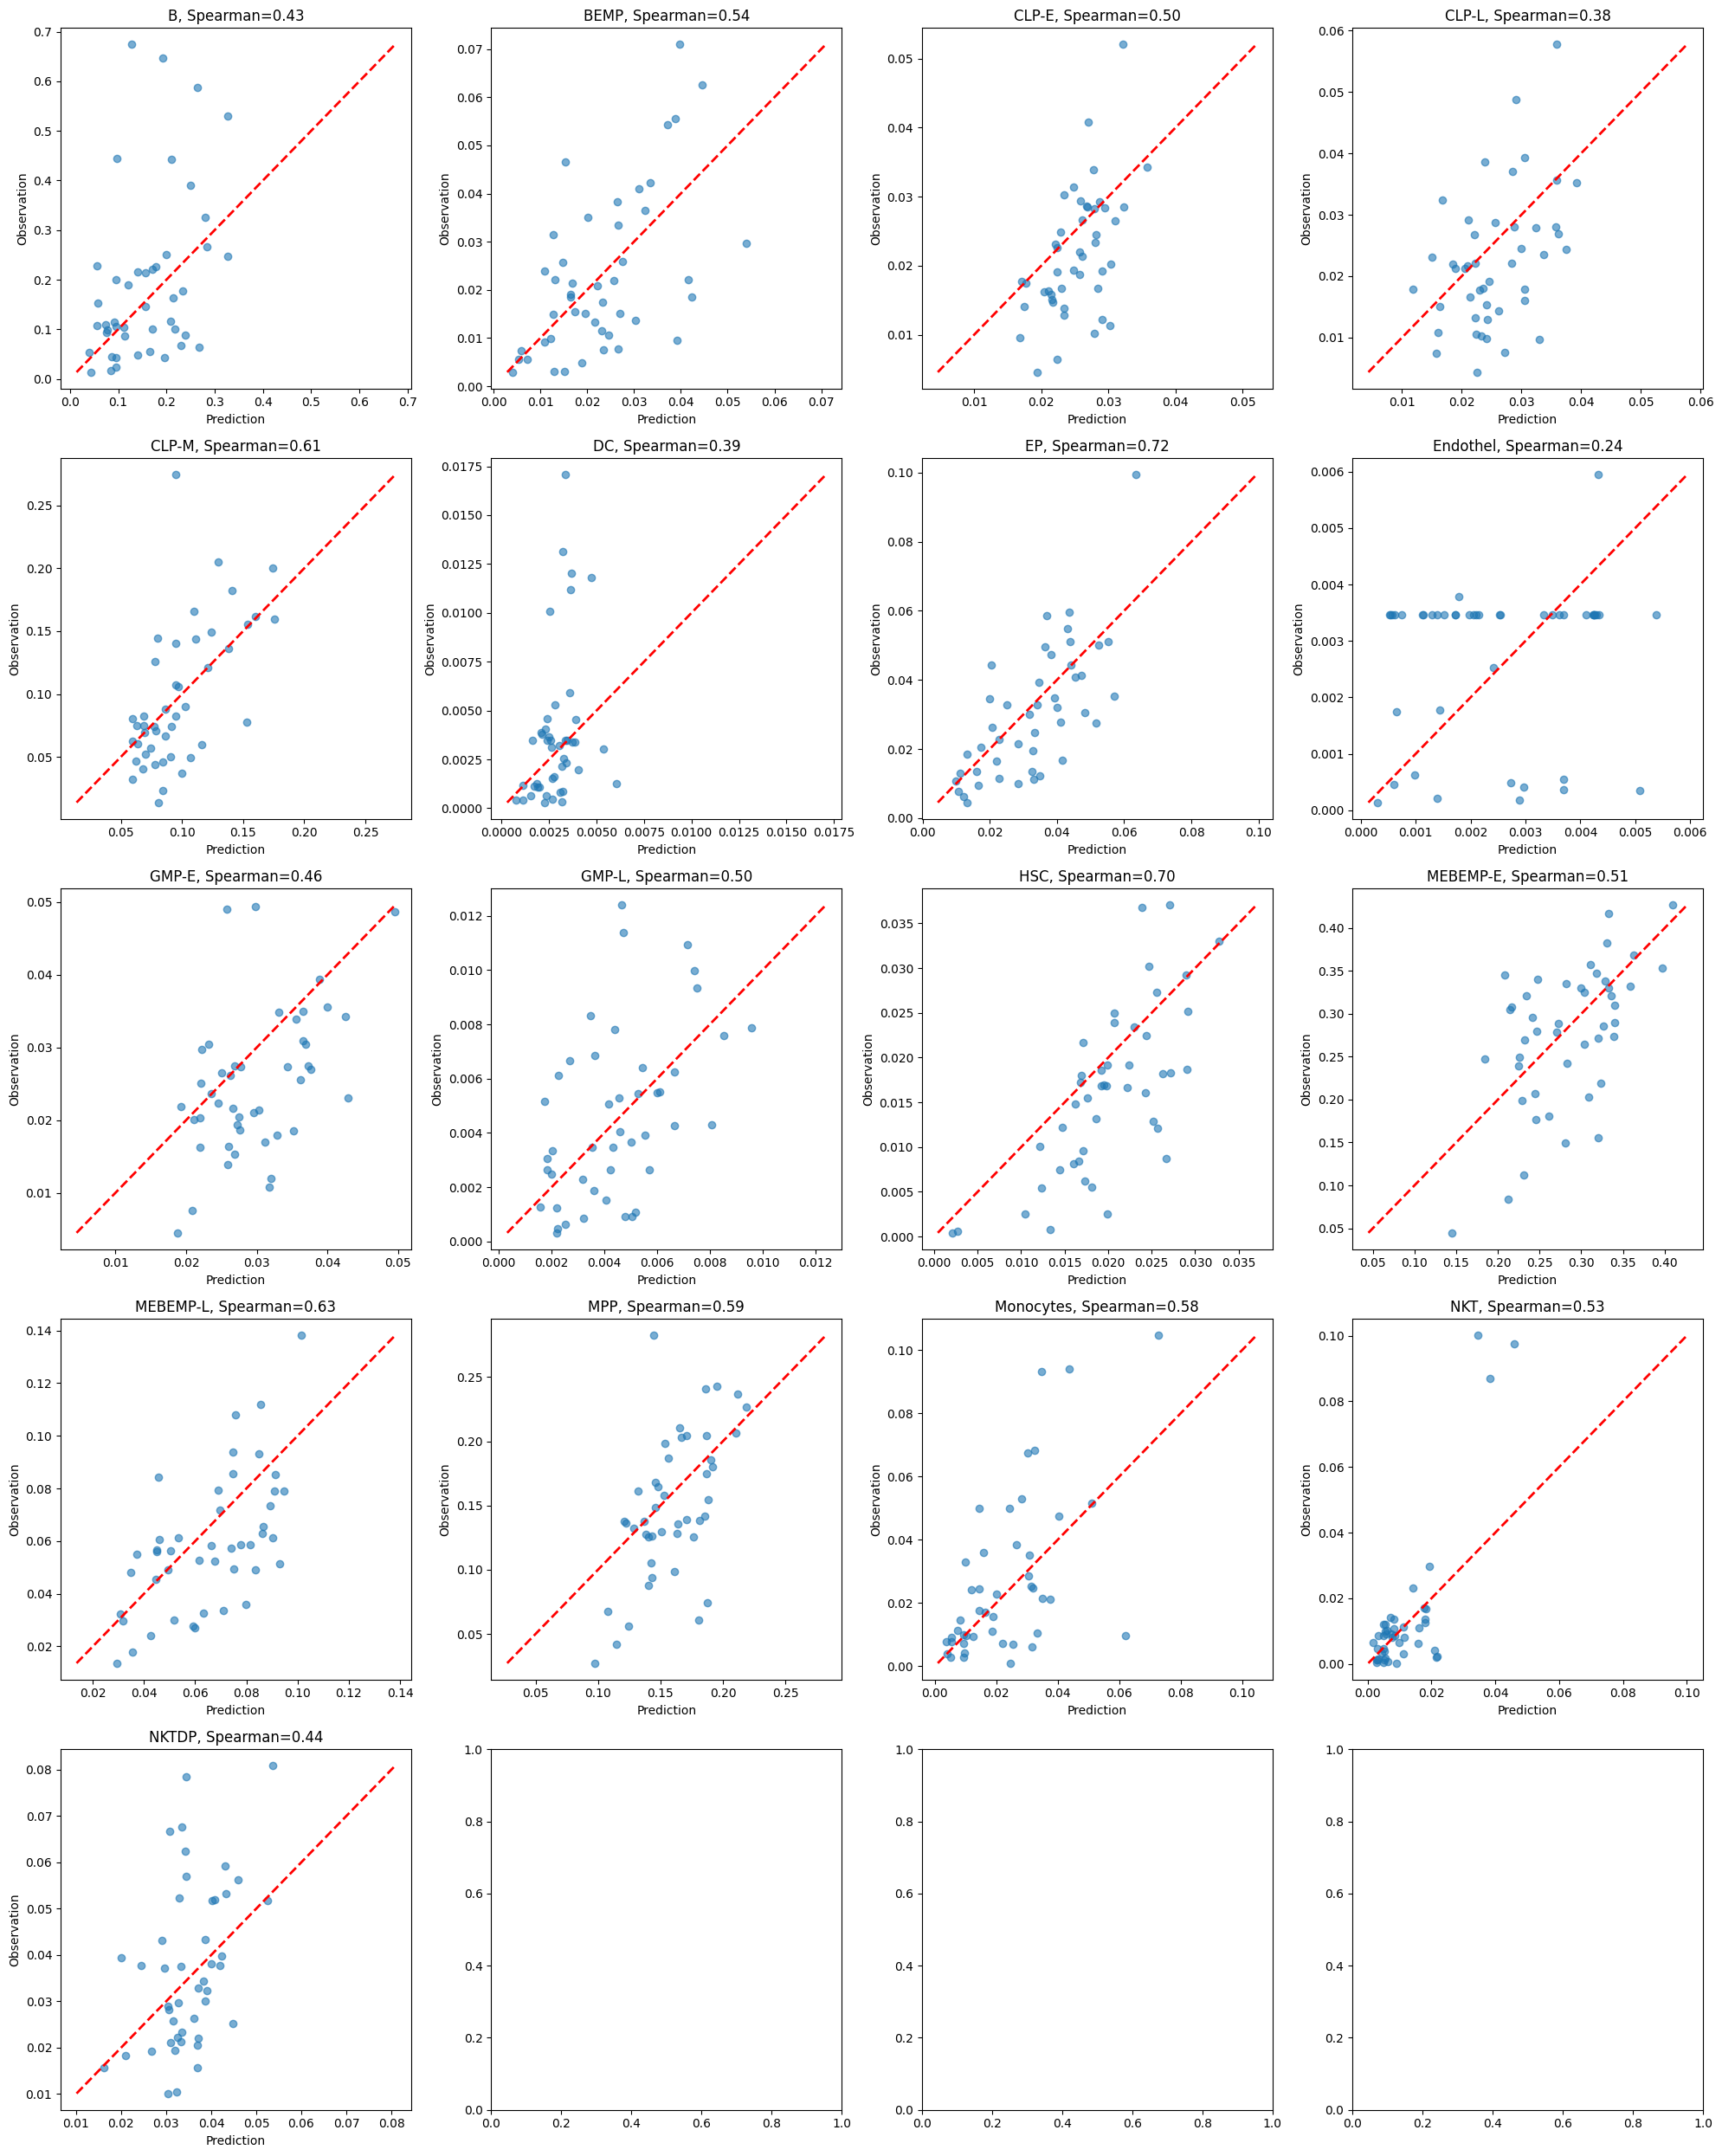

In [158]:
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr

ncols = 4
nrows = round(targets.shape[1]/ncols) + 1

ct_preds = ilr_inv(preds)
ct_obs = ilr_inv(targets)

# ct_cor_init_regression = [np.corrcoef(ct_preds[:, i], ct_obs[:, i])[0][1] for i in range(cell_type_proportions_df.shape[1])]
ct_cor_init_regression = [sp.stats.spearmanr(ct_preds[:, i], ct_obs[:, i])[0] for i in range(cell_type_proportions_df.shape[1])]

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(cell_type_proportions_df.shape[1]):
    axs[i].scatter(ct_preds[:, i].ravel(), ct_obs[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction')
    axs[i].set_ylabel('Observation')
    # axs[i].set_xscale('log')
    # axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Pearson={ct_cor_init_regression[i]:.2f}")
    axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Spearman={ct_cor_init_regression[i]:.2f}")

    min_val = min(ct_preds[:, i].min(), ct_obs[:, i].min())
    max_val = max(ct_preds[:, i].max(), ct_obs[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

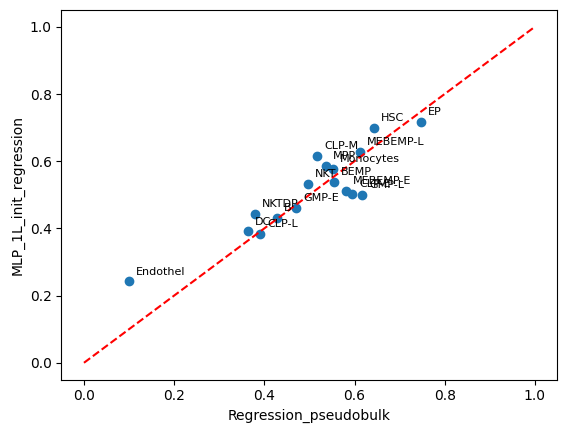

In [148]:
plt.scatter(ct_cor_regression, ct_cor_init_regression)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L_init_regression')

# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_regression[i], ct_cor_init_regression[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)
    

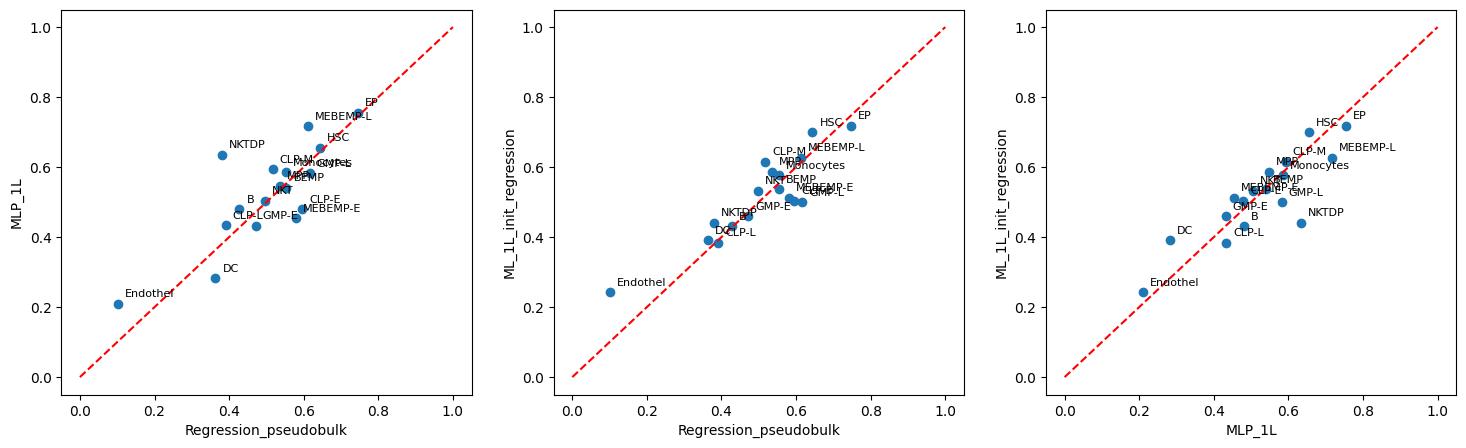

In [149]:
plt.figure(figsize = (18, 5))
plt.subplot(1,3,1)
plt.scatter(ct_cor_regression, ct_cor)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L')

# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_regression[i], ct_cor[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)

plt.subplot(1,3,2)
plt.scatter(ct_cor_regression, ct_cor_init_regression)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('ML_1L_init_regression')


# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_regression[i], ct_cor_init_regression[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)
    
plt.subplot(1,3,3)
plt.scatter(ct_cor, ct_cor_init_regression)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('MLP_1L')
plt.ylabel('ML_1L_init_regression')


# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor[i], ct_cor_init_regression[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)
    

0

# try extending by modelling residual with non-linear layers

In [42]:
import torch
import torch.nn as nn

def init_residual_from_W_regression(model, W_regression, n_covariates, gene_mask, b_regression=None,
                                    device="cuda", dtype=torch.float32):
    lin = model.cell_predictor.linear
    assert isinstance(lin, torch.nn.Linear)

    W_genes_all = torch.as_tensor(W_regression[:, :-n_covariates], dtype=dtype)
    W_genes = W_genes_all[:, gene_mask.cpu()]
    W_cov = torch.as_tensor(W_regression[:, -n_covariates:], dtype=dtype)
    W = torch.hstack((W_genes, W_cov))

    if W.shape != lin.weight.shape:
        raise ValueError(f"Shape mismatch: W {tuple(W.shape)} vs linear {tuple(lin.weight.shape)}")

    with torch.no_grad():
        lin.weight.copy_(W.to(device=device))
        if lin.bias is not None:
            if b_regression is None:
                lin.bias.zero_()
            else:
                lin.bias.copy_(torch.as_tensor(b_regression, dtype=dtype, device=device))

def freeze_linear(model, freeze: bool = True):
    for p in model.cell_predictor.linear.parameters():
        p.requires_grad = not freeze
        

from typing import List, Optional, Sequence, Union, Callable
import torch
import torch.nn as nn

ActivationFactory = Callable[[], nn.Module]

class ResidualPredictor(nn.Module):
    """
    CellPredictor-like module with:
      y = linear(x) + resid(x)

    - Exposes `.network` (like your CellPredictor), so existing code that expects
      `model.cell_predictor.network` will keep working.
    - Also exposes `.linear` and `.resid` for initialization/freezing.
    - Avoids any self-referential `self.network = self` (which caused RecursionError).
    """
    def __init__(self,
                 in_features: int,
                 hidden_features: Union[int, Sequence[int]] = 128,
                 out_features: int = 16,
                 num_hidden_layers: int = 1,
                 activation: bool = True,
                 activation_type: Union[ActivationFactory, Sequence[Optional[ActivationFactory]]] = nn.GELU,
                 out_activation: Optional[nn.Module] = None,
                 dropout: Optional[Union[float, Sequence[float]]] = 0.1,
                 batch_norm: bool = False,
                 layer_norm: bool = True,
                 bias: bool = True,
                 zero_init_residual: bool = True,
                 device: Optional[torch.device] = "cuda",
                 dtype: Optional[torch.dtype] = torch.float32):
        super().__init__()

        # # Linear path (ridge-init goes here)
        self.linear = nn.Linear(in_features, out_features, bias=bias, dtype=dtype)

        # # Residual path (MLP), built similarly to CellPredictor
        hs = [hidden_features] * num_hidden_layers if isinstance(hidden_features, int) else list(hidden_features)

        if activation:
            if callable(activation_type):
                act_fns: List[Optional[ActivationFactory]] = [activation_type] * len(hs)
            else:
                act_fns = list(activation_type)
                if len(act_fns) != len(hs):
                    raise ValueError("activation_type list length must match number of hidden layers")
        else:
            act_fns = [None] * len(hs)

        drops = ([0.0] * len(hs) if dropout is None
                 else ([float(dropout)] * len(hs) if isinstance(dropout, (int, float))
                 else list(dropout)))

        resid_layers: List[nn.Module] = []
        prev = in_features
        # prev = out_features
        for i, h in enumerate(hs):
            resid_layers.append(nn.Linear(prev, h, bias=bias, dtype=dtype))
            if batch_norm:
                resid_layers.append(nn.BatchNorm1d(h, dtype=dtype))
            if layer_norm:
                resid_layers.append(nn.LayerNorm(h, dtype=dtype))
            if act_fns[i] is not None:
                resid_layers.append(act_fns[i]())
            if drops[i] and drops[i] > 0.0:
                resid_layers.append(nn.Dropout(drops[i]))
            prev = h

        # final residual projection to out_features
        resid_layers.append(nn.Linear(prev, out_features, bias=bias, dtype=dtype))
        self.resid = nn.Sequential(*resid_layers)

        # Optional output activation (rare for ILR regression; keep None typically)
        self.out_activation = out_activation

        # Start as pure linear model: make residual initially output ~0
        if zero_init_residual:
            last = self.resid[-1]
            if isinstance(last, nn.Linear):
                nn.init.zeros_(last.weight)
                if last.bias is not None:
                    nn.init.zeros_(last.bias)

        # # Provide `.network` like CellPredictor for compatibility
        # # (This is NOT self-referential; it's just an alias to a real module.)
        self.network = nn.ModuleDict({
            "linear": self.linear,
            "resid": self.resid,
            "out_activation": self.out_activation if self.out_activation is not None else nn.Identity(),
        })

        self.to(device=device, dtype=dtype)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        y = self.linear(X) + self.resid(X)
        if self.out_activation is not None:
            y = self.out_activation(y)
        return y
        # y_linear = self.linear(X)
        # return y_linear + self.resid(y_linear)
        
def run_one_fold_init_regression_residual(data: DataInputs, 
                                         hyperparams: ModelHyperparams, 
                                         setup: TrainSetup, 
                                         fold: int, 
                                         fold_idxs: Dict[str, Any],
                                         W_regression: np.ndarray,
                                         n_covariates: int) -> Dict[str, Any]:
    '''
    DataInputs: a DataClass storing data for training
    hyperparams: a DataClass storing MLP architecture parameters
    setup: a DataClass storing parameters to run the MLP
    fold: the fold ordering (e.g., 0, 1, 2)
    fold_idxs: storing indices of samples for training, validating and testing
    '''
    
    # Unpack for clarity 
    Xs_raw = data.Xs_raw
    Z = data.Z
    Y_imp_ilr = data.Y_imp_ilr
    cell_type_proportions_df = data.cell_type_proportions_df
    
    hidden_features = hyperparams.hidden_features
    num_hidden_layers = hyperparams.num_hidden_layers
    activation = hyperparams.activation
    dropout = hyperparams.dropout
    batch_norm = hyperparams.batch_norm
    bias = hyperparams.bias
    scaling_factor = hyperparams.scaling_factor
    method = hyperparams.method
    layer_norm=hyperparams.layer_norm
    activation_type=hyperparams.activation_type #still factory
    loss_fn=hyperparams.loss_fn(**hyperparams.loss_fn_kwargs) #instantiate the factory here

    
    batch_size = setup.batch_size
    device = setup.device
    epochs = setup.epochs
    lr = setup.lr
    weight_decay = setup.weight_decay
    return_compositions = setup.return_compositions
    use_lr_scheduler = setup.use_lr_scheduler

    # Build datasets for this fold
    datasets, extras = build_datasets_from_indices(
        method=method,
        Xs_raw=Xs_raw,
        Z=Z,
        Y_imp_ilr=Y_imp_ilr,
        cell_type_proportions_df=cell_type_proportions_df,
        indices=fold_idxs,
        dtype=torch.float32,
    )
    # Build loaders (use your compact collate)
    loaders = build_loaders(datasets, batch_size=batch_size, num_workers=0, pin_memory=True, collate_fn=collate_samples_compact)
    loader = loaders["train"]
    loader_val = loaders["val"]
    loader_test = loaders["test"]
    
    # Recompute training-only stats per fold
    gene_mean, gene_std = compute_cellwise_stats(loader, device="cpu")
    tol = 1e-6
    gene_mask = (gene_std > tol)
    G_kept = int(gene_mask.sum().item())
    C = np.asarray(Z).shape[1]
    in_features = G_kept + C
    out_features = (Y_imp_ilr.shape[1] if method.endswith("ilr") else np.asarray(cell_type_proportions_df).shape[1])
    age_column_id = Z.columns.tolist().index('ages')
    train_idx = fold_idxs['train']
    age_mean = Z.iloc[train_idx]['ages'].mean()
    age_std = Z.iloc[train_idx]['ages'].std()
    
    # Build preprocessor and model for this fold
    pre = Preprocessor(gene_mask=gene_mask.to(device=device),
                       gene_mean=gene_mean.to(device=device),
                       gene_std=gene_std.to(device=device),
                       cont_cov_mask=age_column_id,
                       cov_mean=torch.tensor(age_mean).to(device=device),
                       cov_std=torch.tensor(age_std).to(device=device),
                       scaling_factor=scaling_factor,
                       normalize=True)
   
    cell_predictor = ResidualPredictor(
        in_features=in_features,
        out_features=out_features,
        hidden_features=8,
        num_hidden_layers=1,
        dropout=0.1,
        layer_norm=True,
        activation=True,
        activation_type=nn.ReLU,
        out_activation=None,
        device=device,
    )
    

    model = CompositionModel(
        in_features=in_features,
        out_features=out_features,
        method=method,
        aggregator_mode="mean",
        preprocessor=pre,
        cell_predictor = cell_predictor,
        hidden_features=hidden_features, 
        num_hidden_layers=num_hidden_layers, 
        activation=activation,
        dropout=dropout, 
        batch_norm=batch_norm, 
        bias=bias, 
        dtype=torch.float32,
        layer_norm=layer_norm,
        activation_type=activation_type,
    )
    
    #initialize with pseudobulk weights
    # init_from_W_regression(model, W_regression, n_covariates, gene_mask, b_regression=None)
    
    init_residual_from_W_regression(model, W_regression, n_covariates, gene_mask, device=device)

    # train residual only
    freeze_linear(model, freeze = True)   # train residual only


    # Train on this device
    warmup_epochs = min(50, max(10, epochs // 5))
    finetune_epochs = epochs - warmup_epochs
    trainer = Trainer(model, loader, loader_val,
                      lr=lr, weight_decay=weight_decay,
                      epochs=warmup_epochs, recenter_y=(method == "ilr_recenter"),
                      device=device, dtype=torch.float32, verbose=False,
                      use_lr_scheduler=use_lr_scheduler,
                      scheduler_name='cosine',
                      loss_fn = loss_fn,
                      )
    trainer.fit()

    # fine tune
    freeze_linear(model, freeze = False)   


    trainer = Trainer(model, loader, loader_val,
                      lr=lr*0.1, weight_decay=weight_decay,
                      epochs=finetune_epochs, recenter_y=(method == "ilr_recenter"),
                      device=device, dtype=torch.float32, verbose=False,
                      use_lr_scheduler=use_lr_scheduler,
                      scheduler_name='cosine',
                      loss_fn = loss_fn,
                      )
    trainer.fit()
        
    # Evaluate on test
    from torch.nn.functional import mse_loss
    test_res = evaluate_on_loader(trainer.model, loader_test, device=trainer.device,
                                  recenter_y=trainer.recenter_y, y_mean=trainer.y_mean,
                                  return_compositions=return_compositions, method=method)
    test_mse = mse_loss(test_res["preds"], test_res["targets"], reduction="mean").item()
    
    # include checking on cell type
    cor_list = []
    rsq_list = []
    if test_res.get("preds_comp") != None and test_res.get("targets_comp") != None:
        preds_ct = test_res["preds_comp"].cpu().numpy()
        targets_ct = test_res["targets_comp"].cpu().numpy()
        cor_list = [np.corrcoef(preds_ct[:, i], targets_ct[:, i], rowvar=False)[0][1] for i in range(preds_ct.shape[1])]
        def rsquared_feature(Y_pred, Y_obs):
            SSE = np.sum((Y_pred - Y_obs)**2, axis = 0)
            SST = np.sum((Y_obs - np.mean(Y_obs, axis = 0))**2, axis = 0)
            return 1 - SSE / SST
        rsq_list = [rsquared_feature(preds_ct[:, i], targets_ct[:, i]) for i in range(preds_ct.shape[1])]

    return {"fold": fold,
            "train_mse_history": list(trainer.train_mse_history),
            "val_mse_history": list(trainer.val_mse_history),
            "test_mse": test_mse,
            "cor_list": cor_list, #for cell type
            "rsq_list": rsq_list,
            "test_res": test_res,
            "trainer": trainer
            }


In [540]:

fold = 0
fold_idxs = folds[fold]
res_init_regression_residual = run_one_fold_init_regression_residual(data, hyperparams, setup, 
                                                   fold=fold, fold_idxs=fold_idxs,
                                                   W_regression = W_regression,
                                                   n_covariates = Z.shape[1])


 14%|█▍        | 131/950 [02:32<15:54,  1.17s/it]


In [541]:
res_init_regression_residual['trainer'].model

CompositionModel(
  (preprocessor): Preprocessor()
  (aggregator): Aggregator()
  (postprocessor): Postprocessor()
  (cell_predictor): ResidualPredictor(
    (linear): Linear(in_features=17465, out_features=16, bias=True)
    (resid): Sequential(
      (0): Linear(in_features=17465, out_features=8, bias=True)
      (1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
      (2): ReLU()
      (3): Dropout(p=0.1, inplace=False)
      (4): Linear(in_features=8, out_features=16, bias=True)
    )
    (network): ModuleDict(
      (linear): Linear(in_features=17465, out_features=16, bias=True)
      (resid): Sequential(
        (0): Linear(in_features=17465, out_features=8, bias=True)
        (1): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
        (2): ReLU()
        (3): Dropout(p=0.1, inplace=False)
        (4): Linear(in_features=8, out_features=16, bias=True)
      )
      (out_activation): Identity()
    )
  )
)

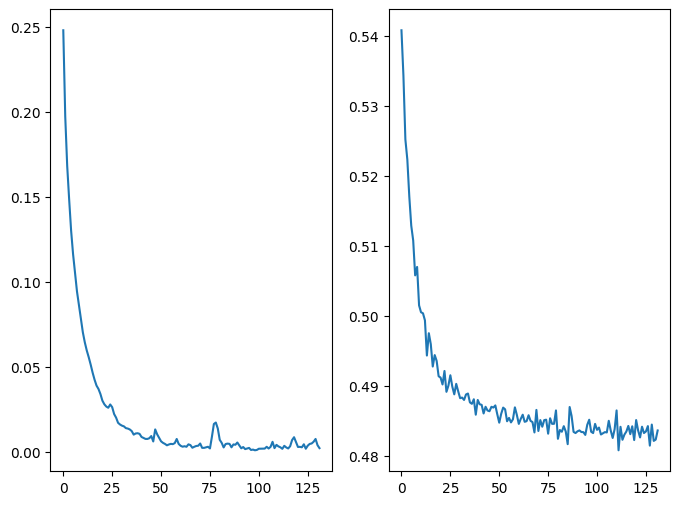

In [542]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8,6))
plt.subplot(1,2,1)
plt.plot(res_init_regression_residual['train_mse_history'])
plt.subplot(1,2,2)
plt.plot(res_init_regression_residual['val_mse_history'])

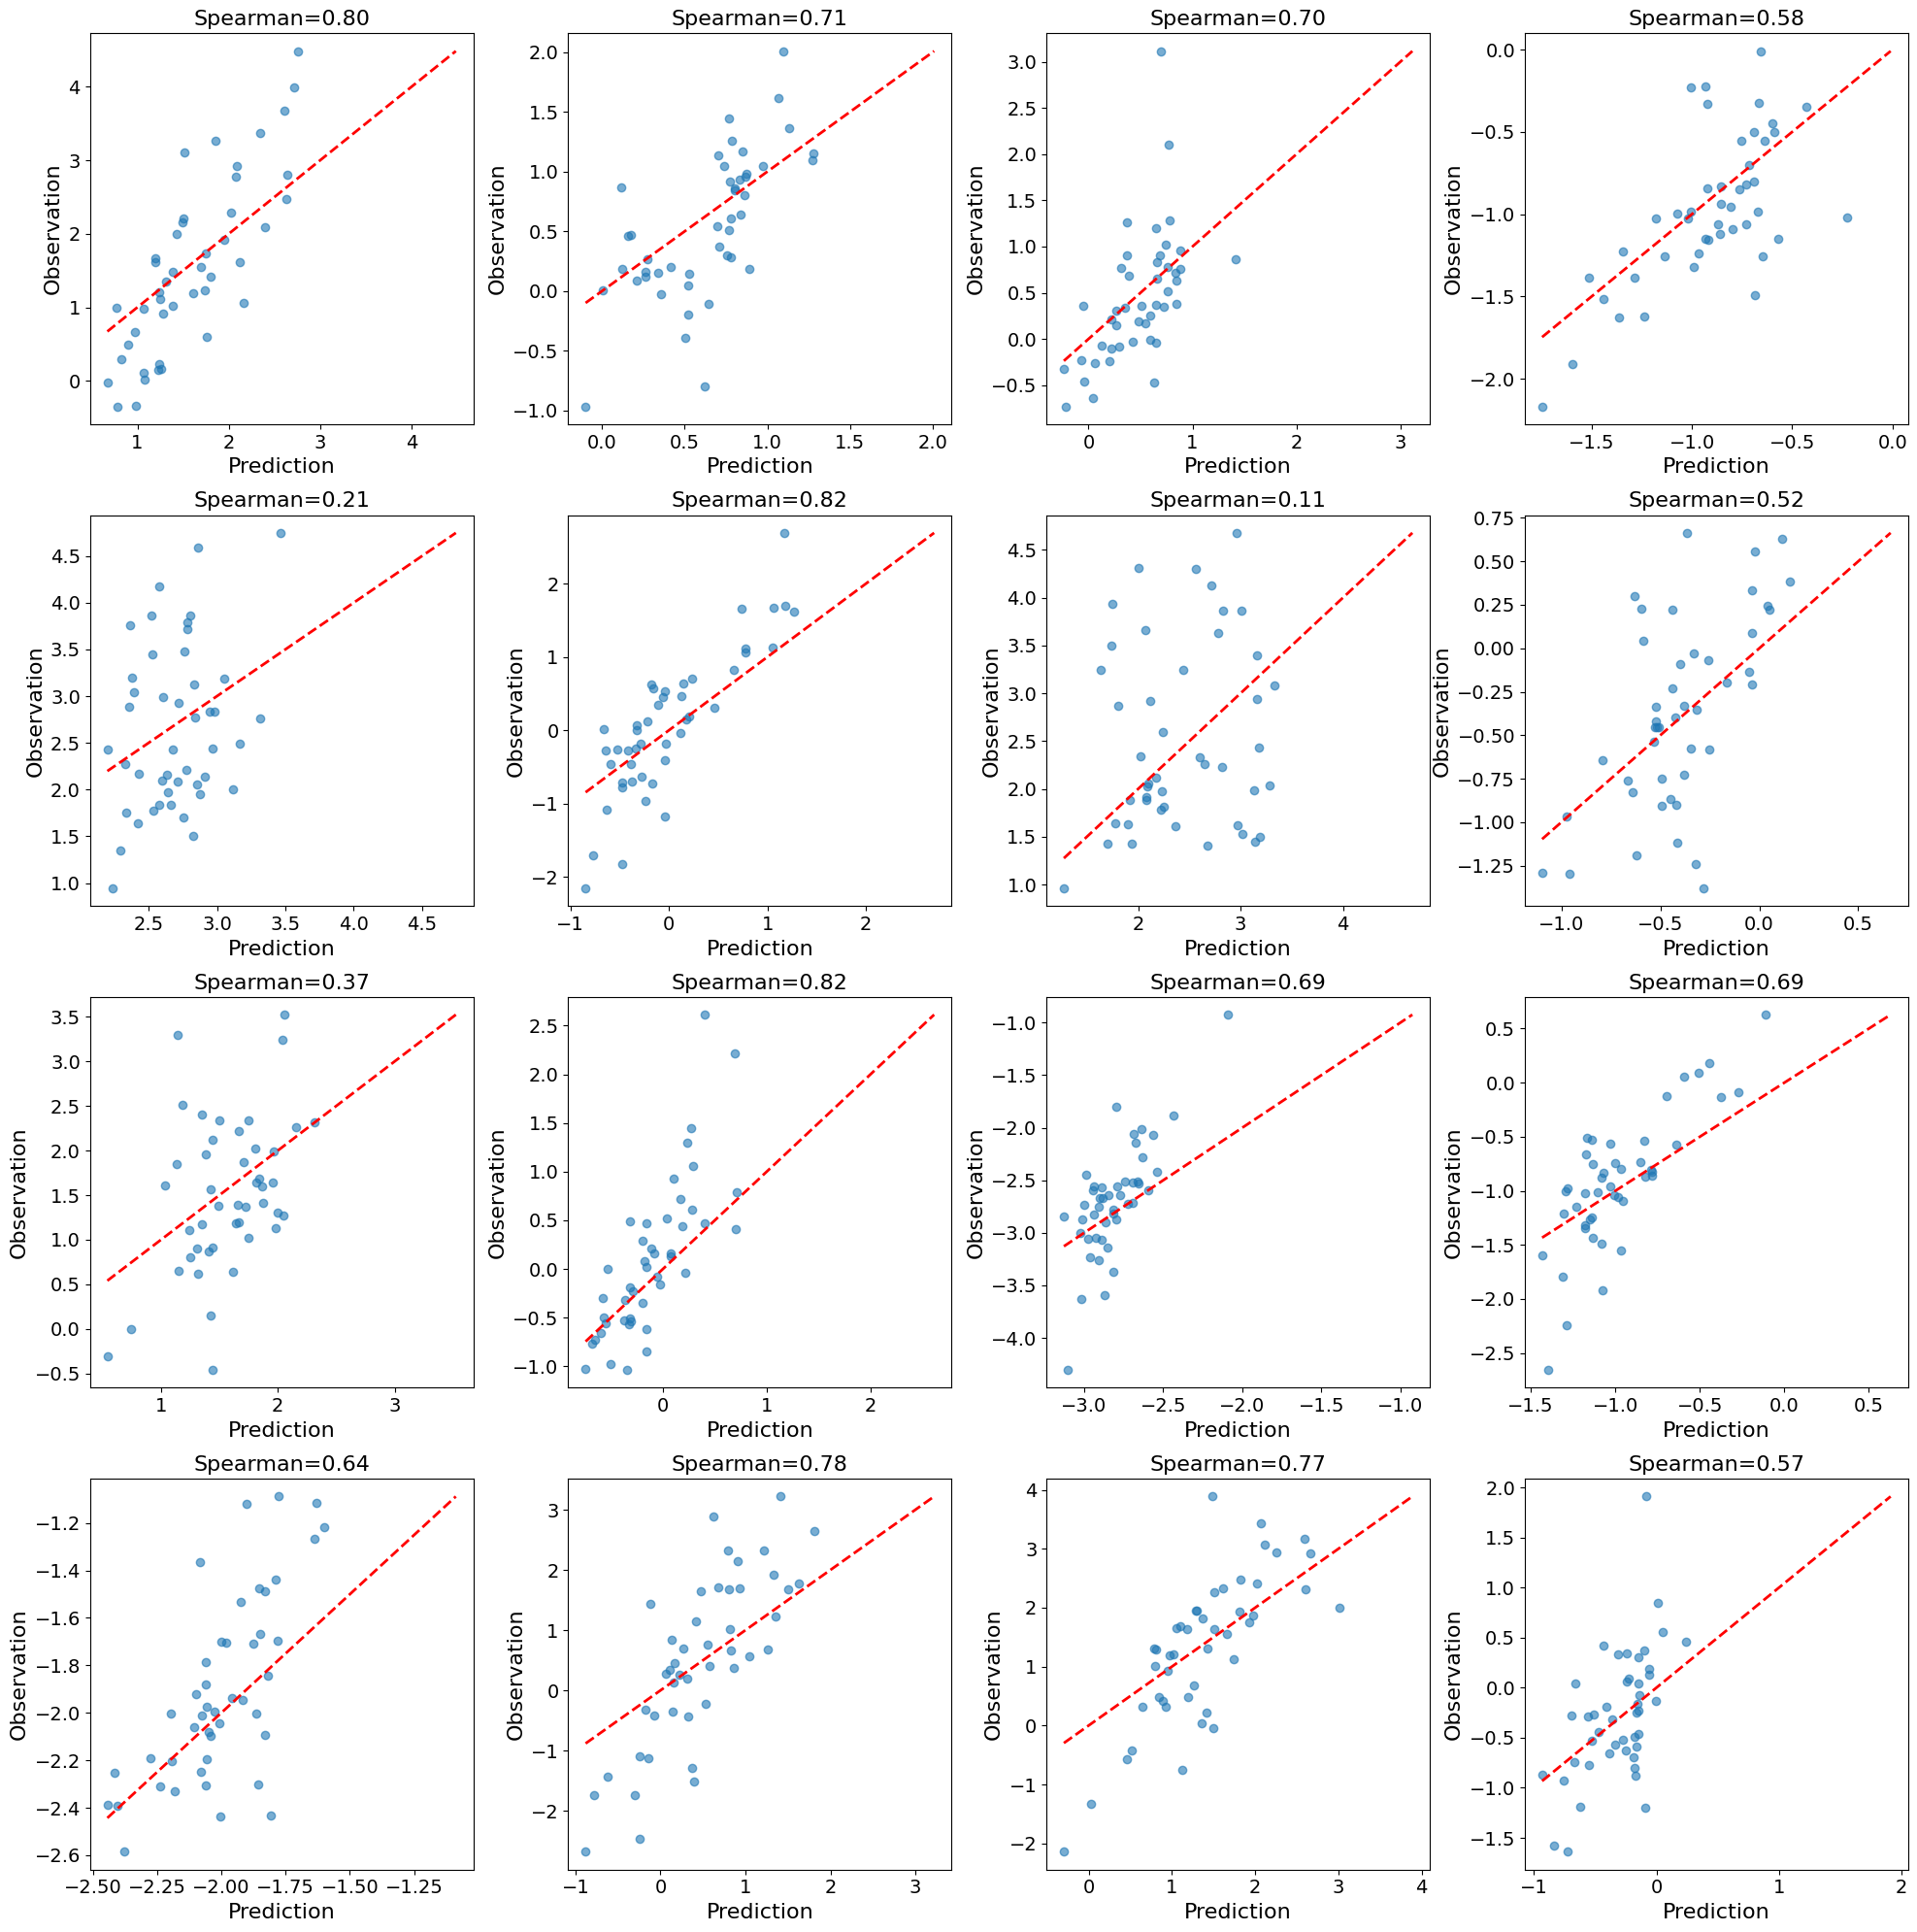

In [543]:
results = res_init_regression_residual['test_res']
preds = results["preds"]             # (S_test, T) aligned with dataset_test indices
targets = results["targets"]         # (S_test, T)
ct_cor_list = res_init_regression_residual['cor_list']

from scipy.stats import pearsonr, spearmanr
# cor_list_residual = [pearsonr(preds[:, i], targets[:, i])[0] for i in np.arange(targets.shape[1])]
cor_list_residual = [spearmanr(preds[:, i], targets[:, i])[0] for i in np.arange(targets.shape[1])]

ncols = 4
nrows = round(Y_test.shape[1]/ncols) 

fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(Y_test.shape[1]):
    axs[i].scatter(preds[:,i].ravel(), targets[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction', fontsize = 16)
    axs[i].set_ylabel('Observation', fontsize = 16)
    axs[i].tick_params(axis = 'both', labelsize = 14)
    # axs[i].set_xscale('log')
    # axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}")
    # axs[i].set_title(f"Pearson={cor_list_residual[i]:.2f}", fontsize = 16)
    axs[i].set_title(f"Spearman={cor_list_residual[i]:.2f}", fontsize = 16)

    min_val = min(preds[:, i].min(), preds[:, i].min())
    max_val = max(targets[:, i].max(), targets[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()


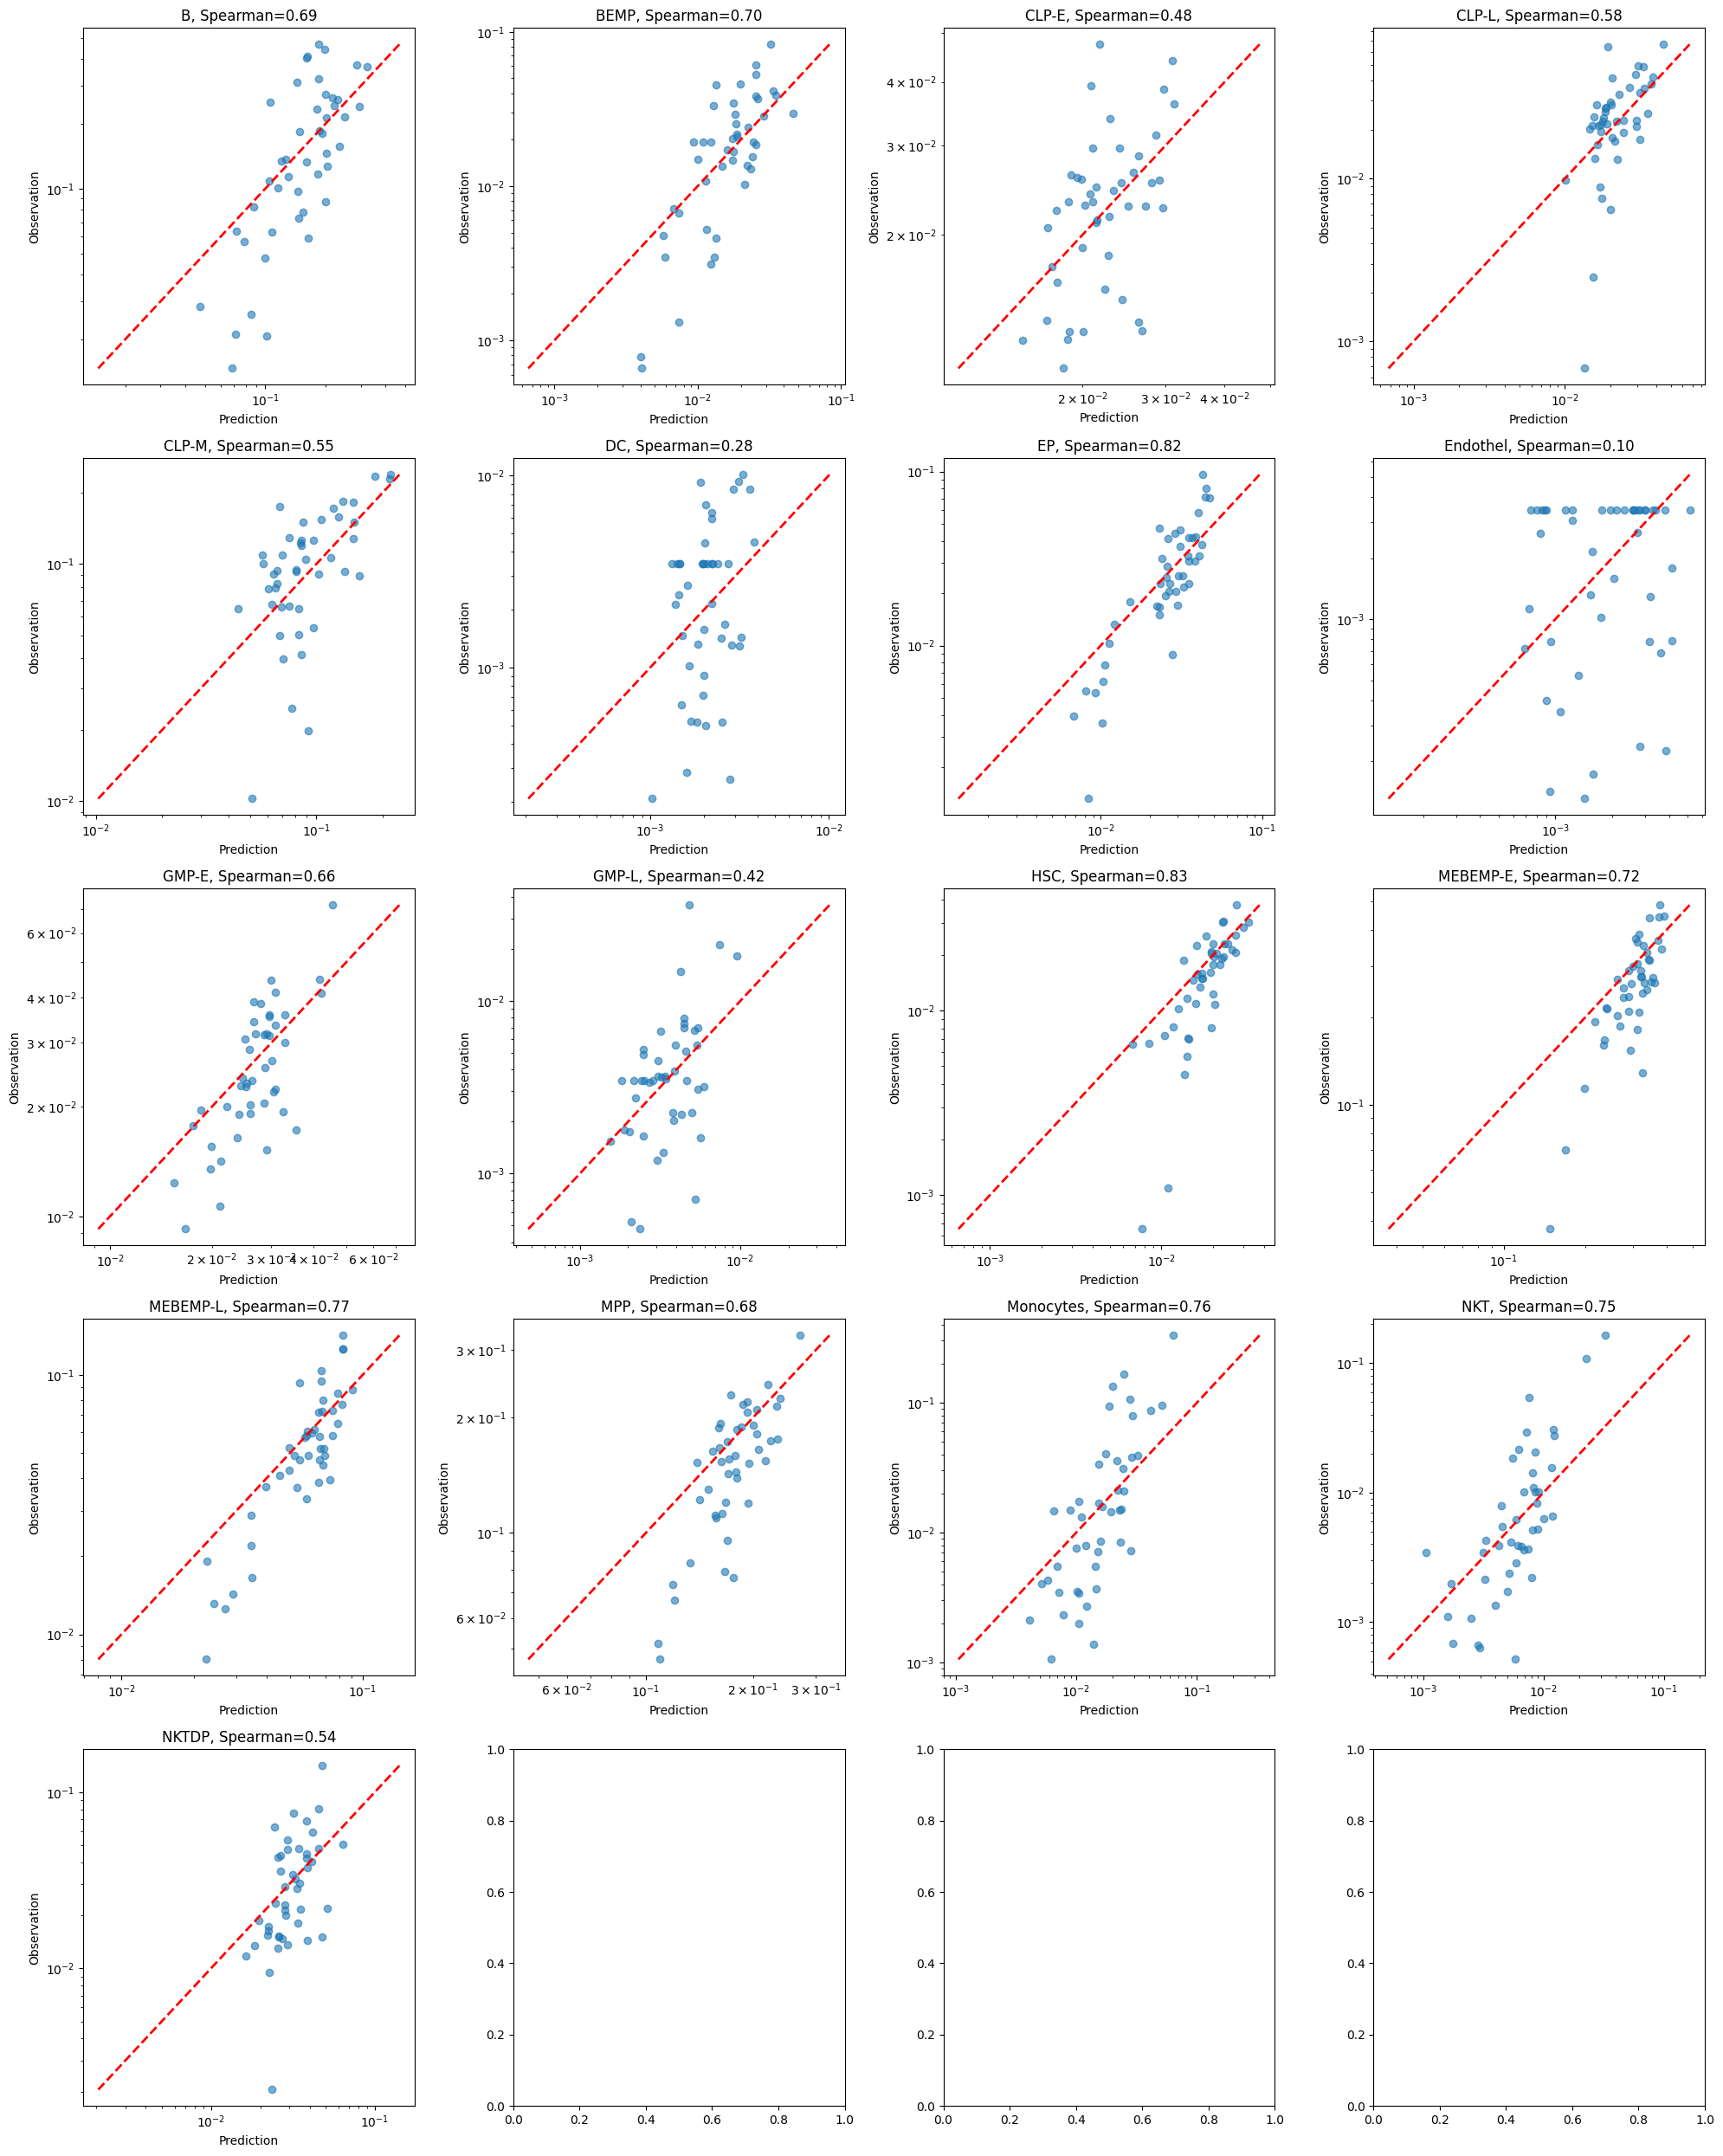

In [544]:
from skbio.stats.composition import closure, multiplicative_replacement, ilr, ilr_inv, clr

ncols = 4
nrows = round(targets.shape[1]/ncols) + 1

ct_preds = ilr_inv(preds)
ct_obs = ilr_inv(targets)

# ct_cor_residual = [np.corrcoef(ct_preds[:, i], ct_obs[:, i])[0][1] for i in range(cell_type_proportions_df.shape[1])]
ct_cor_residual = [sp.stats.spearmanr(ct_preds[:, i], ct_obs[:, i])[0] for i in range(cell_type_proportions_df.shape[1])]


fig, axs = plt.subplots(nrows, ncols, figsize = (5 * ncols, 5 * nrows))
axs = axs.flatten()

for i in range(cell_type_proportions_df.shape[1]):
    axs[i].scatter(ct_preds[:, i].ravel(), ct_obs[:, i].ravel(), alpha = 0.6)
    axs[i].set_xlabel('Prediction')
    axs[i].set_ylabel('Observation')
    axs[i].set_xscale('log')
    axs[i].set_yscale('log')
    # axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Pearson={ct_cor_residual[i]:.2f}")
    axs[i].set_title(f"{cell_type_proportions_df.columns.tolist()[i]}, Spearman={ct_cor_residual[i]:.2f}")

    min_val = min(ct_preds[:, i].min(), ct_obs[:, i].min())
    max_val = max(ct_preds[:, i].max(), ct_obs[:, i].max())
    axs[i].plot([min_val, max_val], [min_val, max_val], 'r--', lw = 2)

fig.tight_layout()
plt.show()

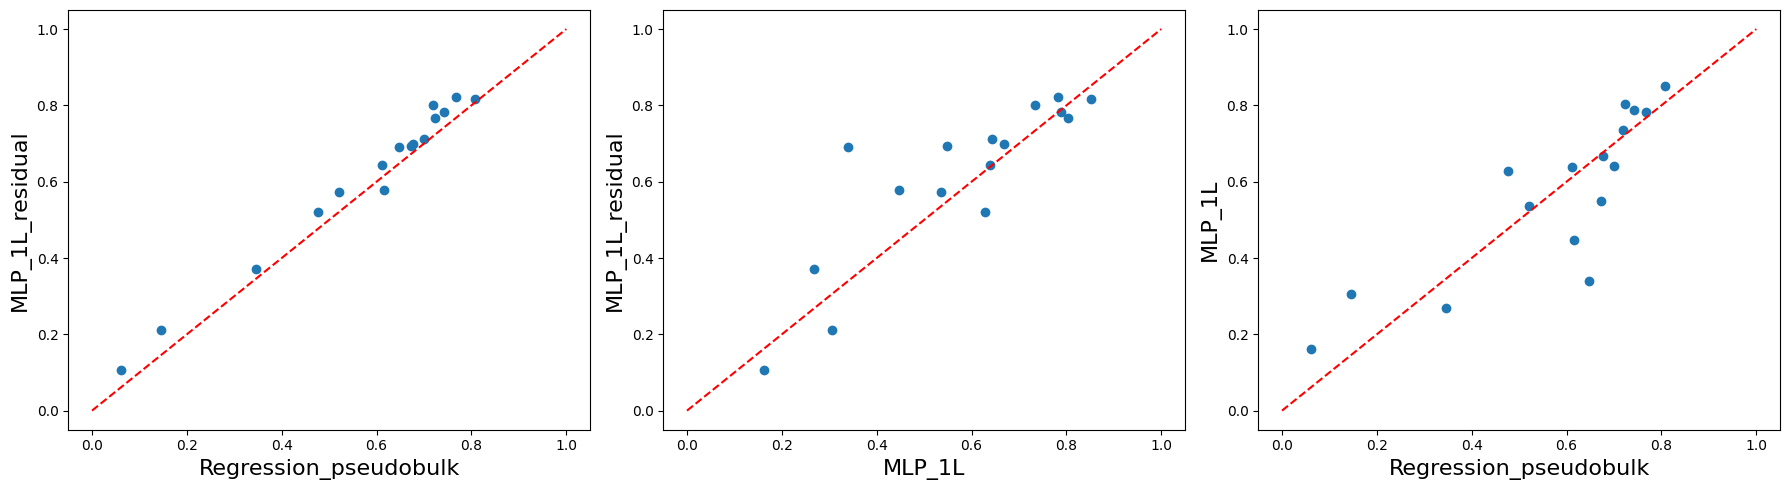

In [545]:
plt.figure(figsize = (18, 5))
plt.subplot(1,3,1)
plt.scatter(cor_list_regression, cor_list_residual)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk', fontsize = 16)
plt.ylabel('MLP_1L_residual', fontsize = 16)

plt.subplot(1,3,2)
plt.scatter(cor_list, cor_list_residual)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('MLP_1L', fontsize = 16)
plt.ylabel('MLP_1L_residual', fontsize = 16)

plt.subplot(1,3,3)
plt.scatter(cor_list_regression, cor_list)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk', fontsize = 16)
plt.ylabel('MLP_1L', fontsize = 16)

plt.tight_layout()
plt.show()

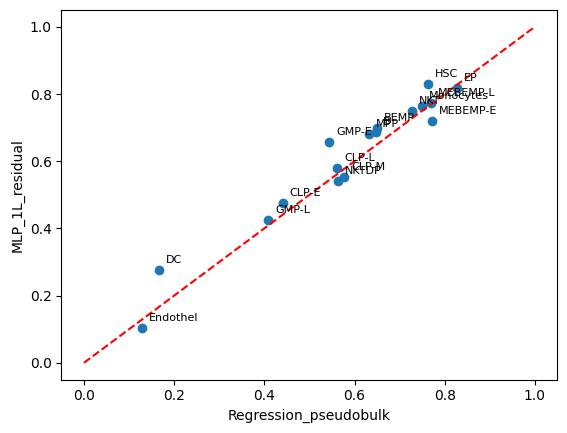

In [546]:
plt.scatter(ct_cor_regression, ct_cor_residual)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L_residual')

# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_regression[i], ct_cor_residual[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)



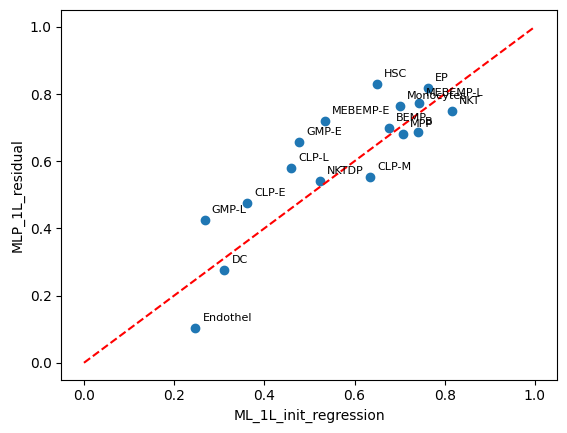

In [547]:
plt.scatter(ct_cor_init_regression, ct_cor_residual)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('ML_1L_init_regression')
plt.ylabel('MLP_1L_residual')

# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_init_regression[i], ct_cor_residual[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)
    

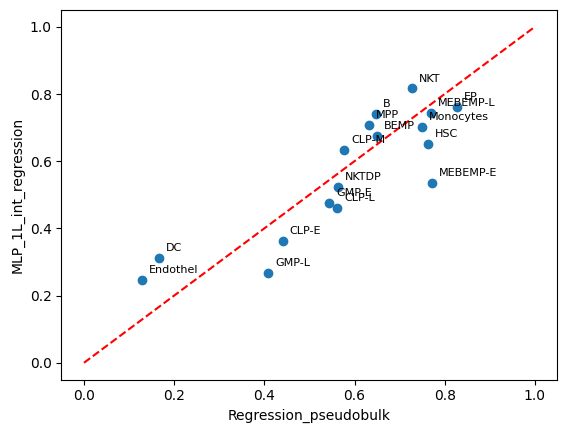

In [548]:
plt.scatter(ct_cor_regression, ct_cor_init_regression)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('Regression_pseudobulk')
plt.ylabel('MLP_1L_int_regression')

# Annotate each point
for i, ct in enumerate(cell_type_proportions_df.columns.tolist()):
    plt.annotate(ct, 
                 (ct_cor_regression[i], ct_cor_init_regression[i]),
                 xytext=(5, 5),  # offset in points
                 textcoords='offset points',
                 fontsize=8)
    

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from skbio.stats.composition import ilr

# ----------------------------
# # Basis + transforms
# ----------------------------
def skbio_default_ilr_basis(D: int, eps: float = 1e-12) -> np.ndarray:
    X = np.full((D, D), eps, dtype=float)
    np.fill_diagonal(X, 1.0)
    X = X / X.sum(axis=1, keepdims=True)
    Y = ilr(X)      # (D, D-1)
    L = np.log(X)   # (D, D)
    V, *_ = np.linalg.lstsq(L, Y, rcond=None)  # (D, D-1)
    return V

def ilr_to_comp_torch(y_ilr: torch.Tensor, V: torch.Tensor) -> torch.Tensor:
    logp = y_ilr @ V.T
    return torch.softmax(logp, dim=1)

def clr_torch(p: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    p = torch.clamp(p, min=eps)
    logp = torch.log(p)
    return logp - logp.mean(dim=1, keepdim=True)

# ----------------------------
# # Loss
# ----------------------------
class ILRPlusCompLoss(nn.Module):
    def __init__(
        self,
        V: torch.Tensor,
        alpha_ilr: float = 0.8,     # weight on ILR MSE
        beta_ait: float = 0.2,      # weight on Aitchison (CLR-MSE)
        gamma_logp: float = 0.2,    # weight on log-proportion MSE (proxy for correlation)
        eps: float = 1e-8,
        celltype_weights: torch.Tensor | None = None,  # shape (D,)
    ):
        super().__init__()
        self.register_buffer("V", V)
        self.alpha_ilr = float(alpha_ilr)
        self.beta_ait = float(beta_ait)
        self.gamma_logp = float(gamma_logp)
        self.eps = eps
        self.mse = nn.MSELoss(reduction="mean")
        if celltype_weights is not None:
            self.register_buffer("w", celltype_weights)
        else:
            self.w = None

    def forward(self, yhat_ilr: torch.Tensor, y_ilr_true: torch.Tensor, p_true: torch.Tensor) -> torch.Tensor:
        # # ILR MSE
        loss_ilr = self.mse(yhat_ilr, y_ilr_true)

        # # Convert prediction to composition
        p_hat = ilr_to_comp_torch(yhat_ilr, self.V)

        # # Aitchison (CLR-MSE)
        clr_hat = clr_torch(p_hat, eps=self.eps)
        clr_true = clr_torch(p_true, eps=self.eps)
        loss_ait = ((clr_hat - clr_true) ** 2).mean()

        # # Log-proportion MSE (helps per-cell-type correlation)
        log_hat = torch.log(torch.clamp(p_hat, min=self.eps))
        log_true = torch.log(torch.clamp(p_true, min=self.eps))
        if self.w is None:
            loss_logp = ((log_hat - log_true) ** 2).mean()
        else:
            # normalize weights to keep scale stable
            w = self.w / self.w.mean()
            loss_logp = (((log_hat - log_true) ** 2) * w[None, :]).mean()

        return self.alpha_ilr * loss_ilr + self.beta_ait * loss_ait + self.gamma_logp * loss_logp